### Set Up

In [2]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "Foundation_DR1.zip"


In [5]:
try:
    with ZipFile(lsst_zip, "r") as archive:
        all_entries = archive.namelist()

    print("Number of ZIP entries:", len(all_entries))
    print(*all_entries[:30], sep="\n")

except FileNotFoundError:
    print(f"File not found: {lsst_zip.resolve()}")

except BadZipFile:
    print("The file exists but is not a valid ZIP archive.")

Number of ZIP entries: 185
Foundation_DR1/
Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Foundation_DR1/Foundation_DR1_PS15asb.txt
Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt
Foundation_DR1/Foundation_DR1_PS15mt.txt
Foundation_DR1/Foundation_DR1_PS15bwh.txt
Foundation_DR1/Foundation_DR1_SN2016coj.txt
Foundation_DR1/Foundation_DR1_AT2016gmg.txt
Foundation_DR1/Foundation_DR1_ASASSN-16dw.txt
Foundation_DR1/Foundation_DR1_ASASSN-16ip.txt
Foundation_DR1/Foundation_DR1_ASASSN-16hc.txt
Foundation_DR1/Foundation_DR1_PS16axi.txt
Foundation_DR1/Foundation_DR1_PS15adh.txt
Foundation_DR1/Foundation_DR1_SN2017cpu.txt
Foundation_DR1/Foundation_DR1_ASASSN-16db.txt
Foundation_DR1/Foundation_DR1_ASASSN-15tz.txt
Foundation_DR1/Foundation_DR1_SN2016ayg.txt
Foundation_DR1/Foundation_DR1_PS15bzz.txt
Foundation_DR1/Foundation_DR1_SN2017jl.txt
Foundation_DR1/Foundation_DR1_ATLAS17ajs.txt
Foundation_DR1/Foundation_DR1_PS16cvc.txt
Foundation_DR1/Foundation_DR1_iP

In [6]:
with ZipFile(lsst_zip, "r") as archive:
    all_entries = archive.namelist()

    txt_files = [
        name
        for name in all_entries
        if name.lower().endswith(".txt")
        and "__MACOSX" not in Path(name).parts
        and not Path(name).name.startswith("._")
    ]

print("Real light-curve files:", len(txt_files))
print(*txt_files[:10], sep="\n")

Real light-curve files: 180
Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Foundation_DR1/Foundation_DR1_PS15asb.txt
Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt
Foundation_DR1/Foundation_DR1_PS15mt.txt
Foundation_DR1/Foundation_DR1_PS15bwh.txt
Foundation_DR1/Foundation_DR1_SN2016coj.txt
Foundation_DR1/Foundation_DR1_AT2016gmg.txt
Foundation_DR1/Foundation_DR1_ASASSN-16dw.txt
Foundation_DR1/Foundation_DR1_ASASSN-16ip.txt


In [7]:
def decode_text(raw_bytes):
    encodings = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin-1",
    ]

    for encoding in encodings:
        try:
            return raw_bytes.decode(encoding), encoding
        except UnicodeDecodeError:
            continue

    raise ValueError("Could not decode file using supported encodings.")

In [8]:
def read_snana_text_file(archive, filename):
    """
    Read one SNANA-format text light curve from an open ZIP archive.

    Returns
    -------
    metadata : dict
        Object-level information such as SNID, RA and redshift.

    observations : pandas.DataFrame
        One row per OBS measurement.

    encoding : str
        Text encoding used to decode the file.
    """

    with archive.open(filename) as file:
        raw_bytes = file.read()

    text, encoding = decode_text(raw_bytes)
    lines = text.splitlines()

    metadata = {}
    varlist = None
    observation_rows = []

    for raw_line in lines:
        line = raw_line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        if line.startswith("VARLIST:"):
            varlist = line.split(":", 1)[1].split()
            continue

        if line.startswith("OBS:"):
            if varlist is None:
                raise ValueError(
                    f"OBS row found before VARLIST in {filename}"
                )

            values = line.split(":", 1)[1].split()

            if len(values) != len(varlist):
                raise ValueError(
                    f"{filename}: expected {len(varlist)} values, "
                    f"but found {len(values)} in:\n{line}"
                )

            observation_rows.append(values)
            continue

        if line == "END:":
            break

        if ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip()

    if varlist is None:
        raise ValueError(f"No VARLIST found in {filename}")

    observations = pd.DataFrame(
        observation_rows,
        columns=varlist,
    )

    numeric_columns = [
        "MJD",
        "FLUXCAL",
        "FLUXCALERR",
        "MAG",
        "MAGERR",
        "PSF",
    ]

    for column in numeric_columns:
        if column in observations.columns:
            observations[column] = pd.to_numeric(
                observations[column],
                errors="coerce",
            )

    return metadata, observations, encoding

In [12]:
test_file = txt_files[0]

with ZipFile(lsst_zip, "r") as archive:
    test_metadata, test_observations, test_encoding = (
        read_snana_text_file(archive, test_file)
    )

print("File:", test_file)
print("Encoding:", test_encoding)
print("SNID:", test_metadata.get("SNID"))
print("Declared NOBS:", test_metadata.get("NOBS"))
print("Parsed observations:", len(test_observations))

display(test_observations.head())

File: Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Encoding: utf-8
SNID: MASTEROTJ08
Declared NOBS: 25
Parsed observations: 25


,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF
0,57808.43076,g,NULL,21009.444,366.130,16.694,0.019,2.15
1,57825.34020,g,NULL,5969.606,247.777,18.060,0.045,2.76
2,57831.23762,g,NULL,3690.841,111.695,18.582,0.033,1.59
3,57843.29875,g,NULL,2667.690,145.003,18.935,0.059,2.76
4,57859.29519,g,NULL,1521.568,86.161,19.544,0.061,1.96


In [14]:
all_metadata = []
all_observations = []
failed_files = []

with ZipFile(lsst_zip, "r") as archive:

    for filename in txt_files:
        try:
            metadata, observations, encoding = (
                read_snana_text_file(archive, filename)
            )

            snid = metadata.get(
                "SNID",
                Path(filename).stem,
            )

            observations.insert(0, "SNID", snid)
            observations.insert(1, "SOURCE_FILE", filename)

            all_observations.append(observations)

            all_metadata.append({
                "SNID": snid,
                "SOURCE_FILE": filename,
                "TEXT_ENCODING": encoding,
                **metadata,
            })

        except Exception as error:
            failed_files.append({
                "SOURCE_FILE": filename,
                "ERROR": str(error),
            })

In [15]:
metadata_df = pd.DataFrame(all_metadata)

detections_df = pd.concat(
    all_observations,
    ignore_index=True,
)

failed_df = pd.DataFrame(failed_files)

In [16]:
print("Objects loaded:", len(metadata_df))
print("Observation rows loaded:", len(detections_df))
print("Failed real files:", len(failed_df))

Objects loaded: 180
Observation rows loaded: 5709
Failed real files: 0


In [17]:
display(metadata_df.head())

,SNID,SOURCE_FILE,TEXT_ENCODING,SURVEY,SNTYPE,RA,DECL,MWEBV,FILTERS,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL,SEARCH_PEAKMJD,HOSTGAL_LOGMASS,VPEC,VPEC_ERR,PIXSIZE,NOBS,NVAR
0,MASTEROTJ08,Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt,utf-8,FOUNDATION,1,128.2370548,-3.8578969,0.0313 +- 0.0016,griz,0.0305840 +- 0.0001500,0.0315652 +- 0.0001500,0.0315652 +- 0.0001500,57808.43076,6.000 +- 0.100,-140.033,250.000,0.25 # arcsec,25,8
1,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,utf-8,FOUNDATION,1,215.0846629,-9.3009081,0.0456 +- 0.0023,griz,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300,57195.27426,6.000 +- 0.100,277.052,250.000,0.25 # arcsec,30,8
2,ASASSN-15od,Foundation_DR1/Foundation_DR1_ASASSN-15od.txt,utf-8,FOUNDATION,1,35.8049483,-4.5171839,0.0255 +- 0.0013,griz,0.0176030 +- 0.0000130,0.0167840 +- 0.0000130,0.0167840 +- 0.0000130,57255.60389,9.899 +- 0.001,137.894,250.000,0.25 # arcsec,28,8
3,ASASSN-15bc,Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt,utf-8,FOUNDATION,1,61.5609874,-8.8856098,0.0375 +- 0.0019,griz,0.0367150 +- 0.0000970,0.0363880 +- 0.0000970,0.0363880 +- 0.0000970,57046.21469,10.187 +- 0.011,467.851,250.000,0.25 # arcsec,32,8
4,PS15mt,Foundation_DR1/Foundation_DR1_PS15mt.txt,utf-8,FOUNDATION,1,148.6840749,23.1981134,0.0212 +- 0.0011,griz,0.0708500 +- 0.0000880,0.0719258 +- 0.0000880,0.0719258 +- 0.0000880,57105.23788,8.856 +- 0.047,-127.187,250.000,0.25 # arcsec,24,8


In [19]:
metadata_df["NOBS_DECLARED"] = pd.to_numeric(
    metadata_df["NOBS"],
    errors="coerce",
)

parsed_counts = (
    detections_df
    .groupby("SNID")
    .size()
    .rename("NOBS_PARSED")
    .reset_index()
)

nobs_check = metadata_df.merge(
    parsed_counts,
    on="SNID",
    how="left",
)

nobs_mismatches = nobs_check[
    nobs_check["NOBS_DECLARED"]
    != nobs_check["NOBS_PARSED"]
]

print("Objects with an NOBS mismatch:", len(nobs_mismatches))

display(
    nobs_mismatches[
        [
            "SNID",
            "NOBS_DECLARED",
            "NOBS_PARSED",
            "SOURCE_FILE",
        ]
    ]
)

Objects with an NOBS mismatch: 0


,SNID,NOBS_DECLARED,NOBS_PARSED,SOURCE_FILE


In [20]:
detections_df["SNR"] = (
    detections_df["FLUXCAL"]
    / detections_df["FLUXCALERR"]
)

In [21]:
display(
    detections_df[
        [
            "SNID",
            "MJD",
            "FLT",
            "FLUXCAL",
            "FLUXCALERR",
            "SNR",
            "MAG",
            "MAGERR",
        ]
    ].head(20)
)

,SNID,MJD,FLT,FLUXCAL,FLUXCALERR,SNR,MAG,MAGERR
0,MASTEROTJ08,57808.43076,g,21009.444,366.130,57.382471,16.694,0.019
1,MASTEROTJ08,57825.34020,g,5969.606,247.777,24.092656,18.060,0.045
2,MASTEROTJ08,57831.23762,g,3690.841,111.695,33.043923,18.582,0.033
3,MASTEROTJ08,57843.29875,g,2667.690,145.003,18.397481,18.935,0.059
4,MASTEROTJ08,57859.29519,g,1521.568,86.161,17.659591,19.544,0.061
5,MASTEROTJ08,57808.43117,r,20859.204,346.574,60.186869,16.702,0.018
6,MASTEROTJ08,57825.34061,r,10076.315,230.911,43.637224,17.492,0.025
7,MASTEROTJ08,57831.23803,r,7816.771,154.094,50.727290,17.767,0.021
8,MASTEROTJ08,57843.29915,r,5082.476,160.416,31.683099,18.235,0.034
9,MASTEROTJ08,57808.43153,i,12942.264,247.360,52.321572,17.220,0.021


In [22]:
snr3_df = detections_df[
    detections_df["SNR"] > 3
].copy()

print("All observations:", len(detections_df))
print("Observations with SNR > 3:", len(snr3_df))

All observations: 5709
Observations with SNR > 3: 5366


### Examine one transient

In [23]:
snid = "PS15asb"

object_metadata = metadata_df[
    metadata_df["SNID"] == snid
]

object_observations = detections_df[
    detections_df["SNID"] == snid
].sort_values("MJD")

display(object_metadata)
display(object_observations)

,SNID,SOURCE_FILE,TEXT_ENCODING,SURVEY,SNTYPE,RA,DECL,MWEBV,FILTERS,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL,SEARCH_PEAKMJD,HOSTGAL_LOGMASS,VPEC,VPEC_ERR,PIXSIZE,NOBS,NVAR,NOBS_DECLARED
1,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,utf-8,FOUNDATION,1,215.0846629,-9.3009081,0.0456 +- 0.0023,griz,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300,57195.27426,6.000 +- 0.100,277.052,250.000,0.25 # arcsec,30,8,30


,SNID,SOURCE_FILE,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF,SNR
44,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.36042,i,NULL,-2.890,35.478,NaN,13.258,1.72,-0.081459
45,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.37342,i,NULL,56.877,36.247,23.113,0.688,1.72,1.569151
46,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.38637,i,NULL,30.505,32.373,23.789,1.146,1.52,0.942298
47,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.39940,i,NULL,32.558,35.094,23.718,1.164,1.53,0.927737
25,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27426,g,NULL,8079.323,178.252,17.732,0.024,2.17,45.325287
31,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27465,r,NULL,8089.224,155.286,17.730,0.021,1.52,52.092423
37,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27502,i,NULL,4850.825,116.570,18.285,0.026,1.55,41.612979
48,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27538,z,NULL,4423.842,147.164,18.386,0.036,1.45,30.060626
26,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57203.27091,g,NULL,5355.136,213.604,18.178,0.043,2.07,25.070392
32,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57203.27132,r,NULL,5974.526,173.632,18.059,0.031,1.83,34.409130


In [24]:
snid = "PS15asb"

lightcurve = (
    detections_df[detections_df["SNID"] == snid]
    .sort_values("MJD")
    .copy()
)

print(f"Number of observations for {snid}: {len(lightcurve)}")
display(lightcurve.head())

Number of observations for PS15asb: 30


,SNID,SOURCE_FILE,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF,SNR
44,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.36042,i,NULL,-2.890,35.478,NaN,13.258,1.72,-0.081459
45,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.37342,i,NULL,56.877,36.247,23.113,0.688,1.72,1.569151
46,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.38637,i,NULL,30.505,32.373,23.789,1.146,1.52,0.942298
47,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.39940,i,NULL,32.558,35.094,23.718,1.164,1.53,0.927737
25,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27426,g,NULL,8079.323,178.252,17.732,0.024,2.17,45.325287


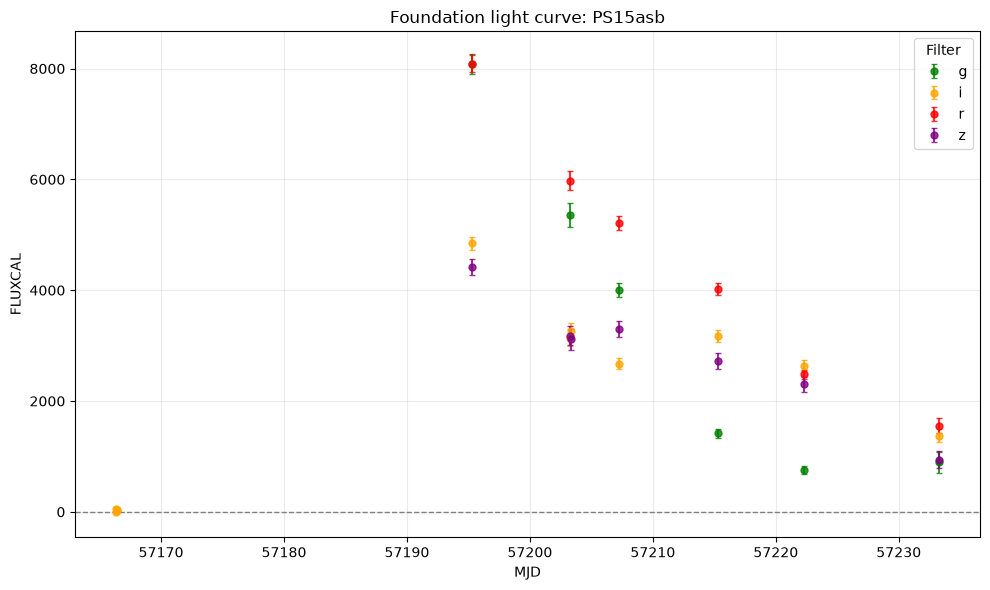

In [25]:
filter_colours = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in lightcurve.groupby("FLT"):
    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.axhline(0, color="grey", linewidth=1, linestyle="--")

ax.set_xlabel("MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"Foundation light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [26]:
peak_mjd = float(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        "SEARCH_PEAKMJD",
    ].iloc[0]
)

lightcurve["PHASE"] = lightcurve["MJD"] - peak_mjd

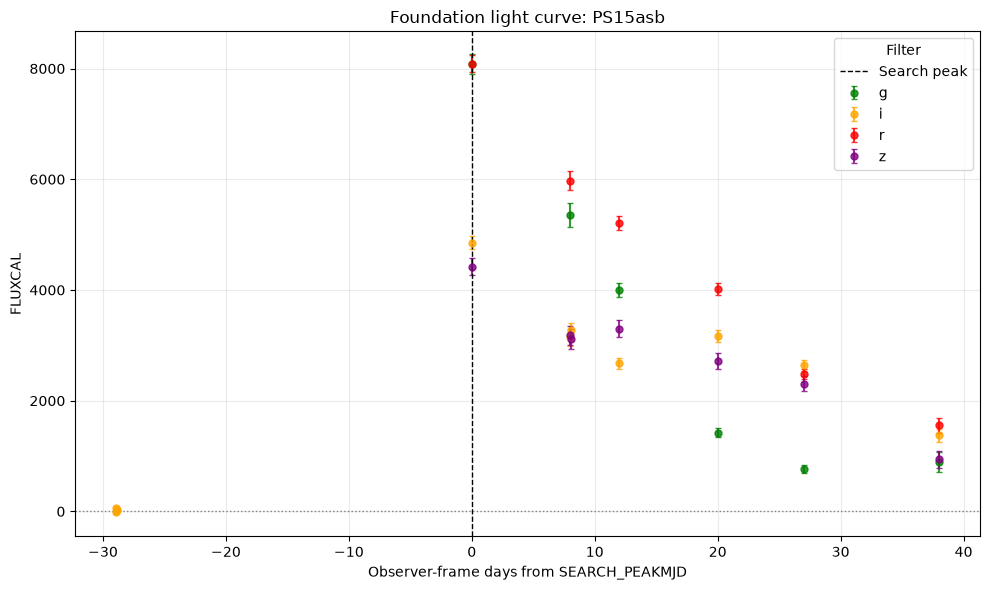

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in lightcurve.groupby("FLT"):
    ax.errorbar(
        band_data["PHASE"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Search peak")
ax.axhline(0, color="grey", linestyle=":", linewidth=1)

ax.set_xlabel("Observer-frame days from SEARCH_PEAKMJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"Foundation light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

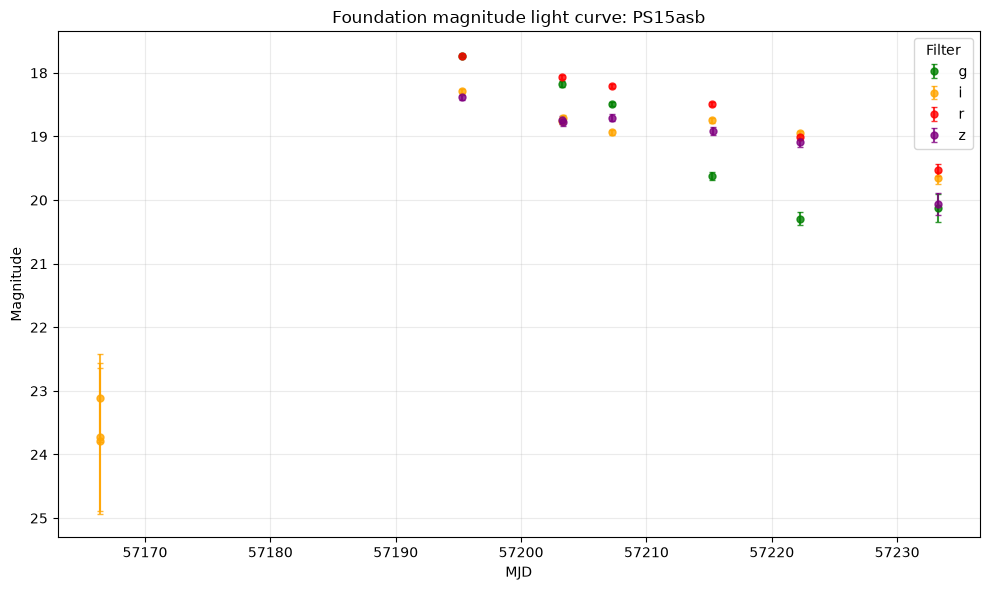

In [28]:
magnitude_data = lightcurve.dropna(
    subset=["MAG", "MAGERR"]
).copy()

fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in magnitude_data.groupby("FLT"):
    ax.errorbar(
        band_data["MJD"],
        band_data["MAG"],
        yerr=band_data["MAGERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.invert_yaxis()

ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.set_title(f"Foundation magnitude light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [29]:
valid_filters = ["g", "r", "i", "z"]

good_rows = (
    detections_df["MJD"].notna()
    & detections_df["FLUXCAL"].notna()
    & detections_df["FLUXCALERR"].notna()
    & (detections_df["FLUXCALERR"] > 0)
    & detections_df["FLT"].isin(valid_filters)
)

clean_detections_df = detections_df[good_rows].copy()

clean_detections_df["SNR"] = (
    clean_detections_df["FLUXCAL"]
    / clean_detections_df["FLUXCALERR"]
)

In [30]:
clean_detections_df["OBS_DAY"] = (
    np.floor(clean_detections_df["MJD"]).astype(int)
)

coverage_df = (
    clean_detections_df.groupby("SNID")
    .agg(
        n_observations=("MJD", "size"),
        n_days=("OBS_DAY", "nunique"),
        n_filters=("FLT", "nunique"),
        lightcurve_span=("MJD", lambda x: x.max() - x.min()),
    )
    .reset_index()
)

display(coverage_df.describe())
display(
    coverage_df.sort_values(
        ["n_filters", "n_days"],
        ascending=False,
    )
)

,n_observations,n_days,n_filters,lightcurve_span
count,180.000000,180.000000,180.0,180.000000
mean,31.716667,8.116667,4.0,80.413023
std,9.101707,2.371325,0.0,94.025809
min,15.000000,4.000000,4.0,20.007970
25%,25.750000,6.000000,4.0,44.973975
50%,30.000000,8.000000,4.0,54.828390
75%,36.000000,9.000000,4.0,71.952375
max,68.000000,18.000000,4.0,709.100540


,SNID,n_observations,n_days,n_filters,lightcurve_span
121,PS15cms,45,18,4,97.03063
101,Gaia16aki,68,17,4,366.02548
26,ASASSN-15so,56,15,4,113.78191
136,PS16em,53,15,4,70.82757
21,ASASSN-15oh,50,14,4,401.07881
...,...,...,...,...,...
172,SN2017coa,19,5,4,46.90881
174,SN2017hn,20,5,4,56.93631
177,SN2017ms,20,5,4,73.72046
80,AT2017lm,16,4,4,47.00483


In [31]:
cols = [
    "SNID",
    "REDSHIFT_HELIO",
    "REDSHIFT_CMB",
    "REDSHIFT_FINAL",
]

display(metadata_df[cols].head(20))

metadata_df["z_helio"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[0]
    .str.strip()
    .astype(float)
)

,SNID,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL
0,MASTEROTJ08,0.0305840 +- 0.0001500,0.0315652 +- 0.0001500,0.0315652 +- 0.0001500
1,PS15asb,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300
2,ASASSN-15od,0.0176030 +- 0.0000130,0.0167840 +- 0.0000130,0.0167840 +- 0.0000130
3,ASASSN-15bc,0.0367150 +- 0.0000970,0.0363880 +- 0.0000970,0.0363880 +- 0.0000970
4,PS15mt,0.0708500 +- 0.0000880,0.0719258 +- 0.0000880,0.0719258 +- 0.0000880
5,PS15bwh,0.0726710 +- 0.0004300,0.0714855 +- 0.0004300,0.0714855 +- 0.0004300
6,SN2016coj,0.0045230 +- 0.0000630,0.0048868 +- 0.0000630,0.0048868 +- 0.0000630
7,AT2016gmg,0.0494370 +- 0.0001070,0.0483916 +- 0.0001070,0.0483916 +- 0.0001070
8,ASASSN-16dw,0.0346570 +- 0.0001500,0.0356503 +- 0.0001500,0.0356503 +- 0.0001500
9,ASASSN-16ip,0.0170080 +- 0.0001000,0.0163238 +- 0.0001000,0.0163238 +- 0.0001000


In [32]:
metadata_df["z_helio"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[0]
    .str.strip()
    .astype(float)
)

metadata_df["z_helio_err"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[1]
    .str.strip()
    .astype(float)
)

In [33]:
snid = "PS15asb"

z = metadata_df.loc[
    metadata_df["SNID"] == snid,
    "z_helio"
].iloc[0]

print(z)

0.04863


### Fitting with BayeSN

In [34]:
model = SEDmodel(
    load_model="T21_model"
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [8]:
filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

In [36]:
snid = "PS15asb"

display(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        [
            "SNID",
            "REDSHIFT_HELIO",
            "MWEBV",
            "SEARCH_PEAKMJD",
            "NOBS",
        ]
        ]
)

,SNID,REDSHIFT_HELIO,MWEBV,SEARCH_PEAKMJD,NOBS
1,PS15asb,0.0486300 +- 0.0003300,0.0456 +- 0.0023,57195.27426,30


In [38]:
from zipfile import ZipFile

extract_dir = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
)

extract_dir.mkdir(
    parents=True,
    exist_ok=True,
)

with ZipFile(lsst_zip, "r") as archive:
    for filename in txt_files:
        archive.extract(
            filename,
            extract_dir,
        )

In [6]:
sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

print(sn_file)
print(sn_file.exists())

/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_ASASSN-15so.txt
True


In [40]:
samples, sn_props = model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    chain_method="sequential",
)

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:37<00:00,  5.13it/s, 63 steps of size 6.06e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:03<00:00,  7.88it/s, 63 steps of size 5.54e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.06      0.08      0.00      0.17    501.57      1.01
          Ds[0]     36.59      0.06     36.59     36.50     36.68    399.67      1.01
 eps_tform[0,0]     -0.56      0.87     -0.56     -2.03      0.82    963.92      1.00
 eps_tform[0,1]      1.02      0.77      1.00     -0.21      2.31    867.51      1.00
 eps_tform[0,2]     -0.03      0.86     -0.02     -1.59      1.27    999.53      1.00
 eps_tform[0,3]     -0.08      0.89     -0.03     -1.43      1.47   1061.51      1.00
 eps_tform[0,4]      1.09      0.72      1.11     -0.27      2.12    853.80      1.00
 eps_tform[0,5]     -0.16      0.77     -0.18     -1.34      1.16    840.71      1.00
 eps_tform[0,6]      0.95      0.76      0.93     -0.08      2.47    841.37      1.00
 eps_tform[0,7]     -0.83      0.69     -0.84     -1.90      0.38   1088.05      1.00
 eps_tform[0,8]     -1.45      0.76     -1.45     -2.

In [41]:
print(sn_props)
print(samples.keys())

(0.04863, 0.0456)
dict_keys(['AV', 'Ds', 'eps', 'eps_tform', 'theta', 'tmax', 'peak_MJD', 'mu', 'delM'])


In [42]:
for name, values in samples.items():
    values = np.asarray(values).reshape(-1)

    q16, q50, q84 = np.percentile(
        values,
        [16, 50, 84],
    )

    print(
        name,
        q50,
        q50 - q16,
        q84 - q50,
    )

AV 0.08074584278160479 0.052616538893193 0.06545891523070552
Ds 36.587130689597565 0.05761450185282513 0.05961560442154479
eps 0.0025049119448095278 0.0886649125542851 0.11168948113693325
eps_tform 0.0880737046719776 1.115839242864345 1.052140021195388
theta 0.75068663443648 0.22277188883003718 0.2129346003251945
tmax -2.667932983561024 0.7822237751197045 0.6689542259206427
peak_MJD 57192.47658543545 0.8202633173059439 0.7014854699227726
mu 36.59579510980444 0.1185506735872508 0.11968659556240624
delM -0.004206204883828946 0.10321002927498511 0.09953222405566547


In [44]:
from bayesn import SEDmodel

plot_model = SEDmodel(
    load_model="T21_model"
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [46]:
t = np.linspace(-10, 40, 200)

bands = [
    "g_PS1",
    "r_PS1",
    "i_PS1",
    "z_PS1",
]

z, ebv_mw = sn_props

flux_grid = plot_model.get_flux_from_chains(
    t,
    bands,
    samples,
    z,
    ebv_mw,
    mag=False,
    num_samples=1000,
)

Getting best fit light curves from chains...


100%|█████████████████████████████████████████████| 1/1 [02:16<00:00, 136.27s/it]


In [47]:
fit = flux_grid.mean(axis=(0, 1))
fit_err = flux_grid.std(axis=(0, 1))

print("flux_grid:", flux_grid.shape)
print("fit:", fit.shape)

snid = "PS15asb"

lc = (
    detections_df[
        detections_df["SNID"] == snid
    ]
    .sort_values("MJD")
    .copy()
)

peak_mjd = float(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        "SEARCH_PEAKMJD",
    ].iloc[0]
)

plot_t = t + peak_mjd

flux_grid: (1, 1000, 4, 200)
fit: (4, 200)


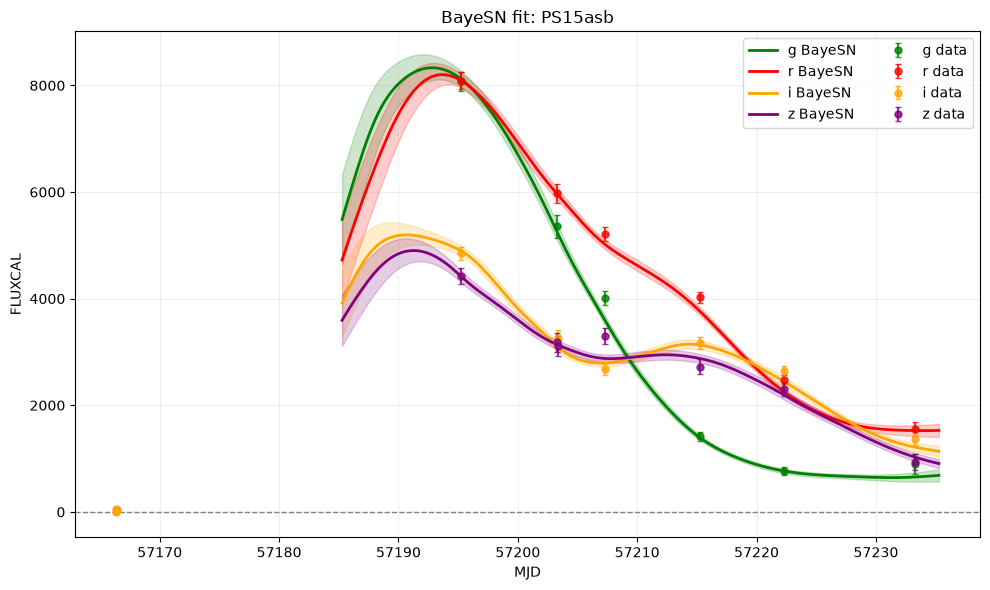

In [48]:
colors = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for b_ind, band in enumerate(["g", "r", "i", "z"]):

    band_data = lc[
        lc["FLT"] == band
    ]

    # observed data
    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=colors[band],
        alpha=0.8,
        label=f"{band} data",
    )

    # BayeSN posterior mean
    ax.plot(
        plot_t,
        fit[b_ind],
        color=colors[band],
        linewidth=2,
        label=f"{band} BayeSN",
    )

    # posterior scatter
    ax.fill_between(
        plot_t,
        fit[b_ind] - fit_err[b_ind],
        fit[b_ind] + fit_err[b_ind],
        color=colors[band],
        alpha=0.2,
    )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"BayeSN fit: {snid}")

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Seeing how different redshifts and light curve quality impact LC fit

In [49]:
snids = [
    "SN2016coj",   # very low z
    "ASASSN-15od",
    "PS15asb",
    "PS15mt",
    "PS15adh",     # higher z
]

In [50]:
# Helper
from bayesn import SEDmodel
import numpy as np

filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

def fit_foundation_sn(snid):

    sn_file = (
        project_root
        / "data"
        / "Foundation_DR1_extracted"
        / "Foundation_DR1"
        / f"Foundation_DR1_{snid}.txt"
    )

    print(f"Fitting {snid}")
    print(sn_file)

    model = SEDmodel(
        load_model="T21_model"
    )

    samples, sn_props = model.fit_from_file(
        str(sn_file),
        filt_map=filt_map,
        photoz=False,
        chain_method="sequential",
    )

    return samples, sn_props

In [51]:
samples, sn_props = fit_foundation_sn(
    "SN2016coj"
)

Fitting SN2016coj
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_SN2016coj.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:01<00:00,  4.11it/s, 127 steps of size 3.80e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:38<00:00,  5.10it/s, 63 steps of size 4.84e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.14      0.06      0.14      0.05      0.23    368.07      1.01
          Ds[0]     31.99      0.05     31.99     31.91     32.06    353.41      1.00
 eps_tform[0,0]      0.30      0.54      0.31     -0.60      1.13    590.63      1.00
 eps_tform[0,1]     -0.11      0.47     -0.13     -0.90      0.63    681.58      1.00
 eps_tform[0,2]     -0.21      0.47     -0.21     -1.01      0.48    804.14      1.00
 eps_tform[0,3]      0.20      0.55      0.18     -0.65      1.16    775.61      1.00
 eps_tform[0,4]      0.08      0.70      0.10     -1.21      1.14    527.50      1.00
 eps_tform[0,5]     -1.41      0.50     -1.41     -2.27     -0.66    707.99      1.00
 eps_tform[0,6]     -0.69      0.59     -0.70     -1.57      0.33    421.24      1.00
 eps_tform[0,7]     -1.24      0.43     -1.23     -1.91     -0.51    378.97      1.01
 eps_tform[0,8]     -1.78      0.64     -1.75     -2.

In [52]:
# Plotting helper

import matplotlib.pyplot as plt

def plot_foundation_fit(
    snid,
    samples,
    sn_props,
    num_samples=100,
    n_phase=80,
):

    # Fresh model because of the internal state issue
    plot_model = SEDmodel(
        load_model="T21_model"
    )

    t = np.linspace(
        -10,
        40,
        n_phase,
    )

    bands = [
        "g_PS1",
        "r_PS1",
        "i_PS1",
        "z_PS1",
    ]

    z, ebv_mw = sn_props

    flux_grid = plot_model.get_flux_from_chains(
        t,
        bands,
        samples,
        z,
        ebv_mw,
        mag=False,
        num_samples=num_samples,
    )

    fit = flux_grid.mean(axis=(0, 1))
    fit_err = flux_grid.std(axis=(0, 1))

    lc = (
        detections_df[
            detections_df["SNID"] == snid
        ]
        .sort_values("MJD")
        .copy()
    )

    peak_mjd = float(
        metadata_df.loc[
            metadata_df["SNID"] == snid,
            "SEARCH_PEAKMJD",
        ].iloc[0]
    )

    plot_t = (
        t + peak_mjd
    )

    colors = {
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
    }

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    for b_ind, band in enumerate(
        ["g", "r", "i", "z"]
    ):

        band_data = lc[
            lc["FLT"] == band
        ]

        ax.errorbar(
            band_data["MJD"],
            band_data["FLUXCAL"],
            yerr=band_data["FLUXCALERR"],
            fmt="o",
            markersize=5,
            capsize=2,
            color=colors[band],
            alpha=0.8,
            label=f"{band} data",
        )

        ax.plot(
            plot_t,
            fit[b_ind],
            color=colors[band],
            linewidth=2,
            label=f"{band} BayeSN",
        )

        ax.fill_between(
            plot_t,
            fit[b_ind] - fit_err[b_ind],
            fit[b_ind] + fit_err[b_ind],
            color=colors[band],
            alpha=0.2,
        )

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
    )

    ax.set_xlabel("MJD")
    ax.set_ylabel("FLUXCAL")
    ax.set_title(
        f"BayeSN fit: {snid}"
    )

    ax.legend(
        ncol=2,
        fontsize=9,
    )

    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

Fitting SN2016coj
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_SN2016coj.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:51<00:00,  4.50it/s, 127 steps of size 3.80e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:37<00:00,  5.11it/s, 63 steps of size 4.84e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.14      0.06      0.14      0.05      0.23    368.07      1.01
          Ds[0]     31.99      0.05     31.99     31.91     32.06    353.41      1.00
 eps_tform[0,0]      0.30      0.54      0.31     -0.60      1.13    590.63      1.00
 eps_tform[0,1]     -0.11      0.47     -0.13     -0.90      0.63    681.58      1.00
 eps_tform[0,2]     -0.21      0.47     -0.21     -1.01      0.48    804.14      1.00
 eps_tform[0,3]      0.20      0.55      0.18     -0.65      1.16    775.61      1.00
 eps_tform[0,4]      0.08      0.70      0.10     -1.21      1.14    527.50      1.00
 eps_tform[0,5]     -1.41      0.50     -1.41     -2.27     -0.66    707.99      1.00
 eps_tform[0,6]     -0.69      0.59     -0.70     -1.57      0.33    421.24      1.00
 eps_tform[0,7]     -1.24      0.43     -1.23     -1.91     -0.51    378.97      1.01
 eps_tform[0,8]     -1.78      0.64     -1.75     -2.

100%|██████████████████████████████████████████████| 1/1 [00:08<00:00,  8.99s/it]


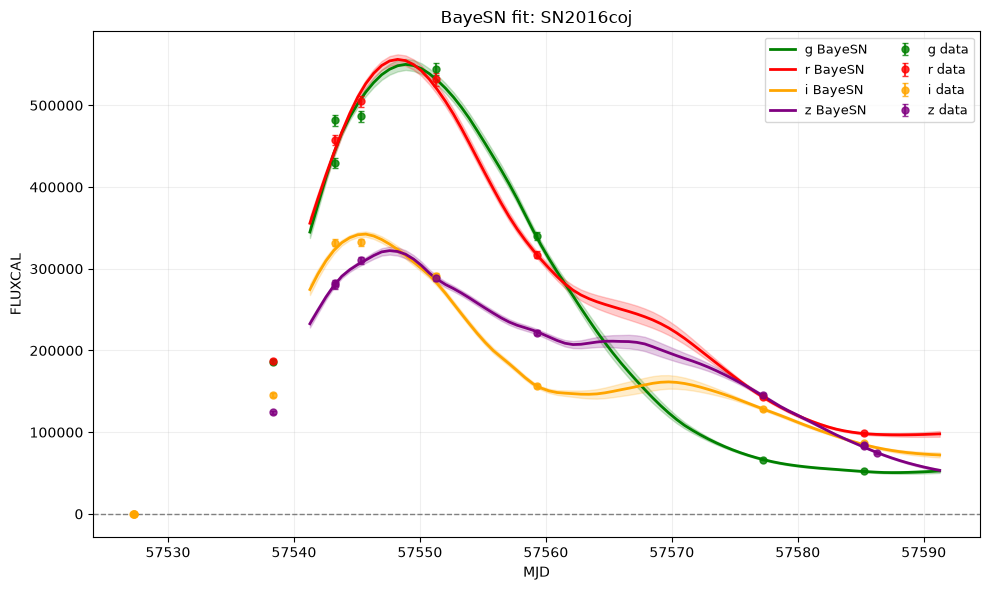

In [53]:
snid = "SN2016coj"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
    num_samples=100,
)

Fitting ASASSN-15od
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:13<00:00,  6.78it/s, 127 steps of size 4.26e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:06<00:00,  7.51it/s, 63 steps of size 5.36e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.04      0.06      0.00      0.12    625.67      1.00
          Ds[0]     34.38      0.04     34.38     34.30     34.45    555.45      1.00
 eps_tform[0,0]      0.29      0.92      0.28     -1.16      1.82   1184.08      1.00
 eps_tform[0,1]     -0.36      0.84     -0.37     -1.73      1.00    963.65      1.00
 eps_tform[0,2]     -0.20      0.89     -0.20     -1.64      1.25    830.96      1.00
 eps_tform[0,3]     -0.18      0.86     -0.16     -1.61      1.23   1178.48      1.00
 eps_tform[0,4]     -0.82      0.70     -0.76     -1.98      0.31    703.46      1.00
 eps_tform[0,5]      0.04      0.61      0.02     -0.98      0.98    874.37      1.00
 eps_tform[0,6]     -0.16      0.59     -0.18     -1.10      0.80    652.24      1.00
 eps_tform[0,7]     -0.57      0.48     -0.59     -1.38      0.20    576.82      1.00
 eps_tform[0,8]      0.23      0.84      0.22     -1.

100%|██████████████████████████████████████████████| 1/1 [00:01<00:00,  1.07s/it]


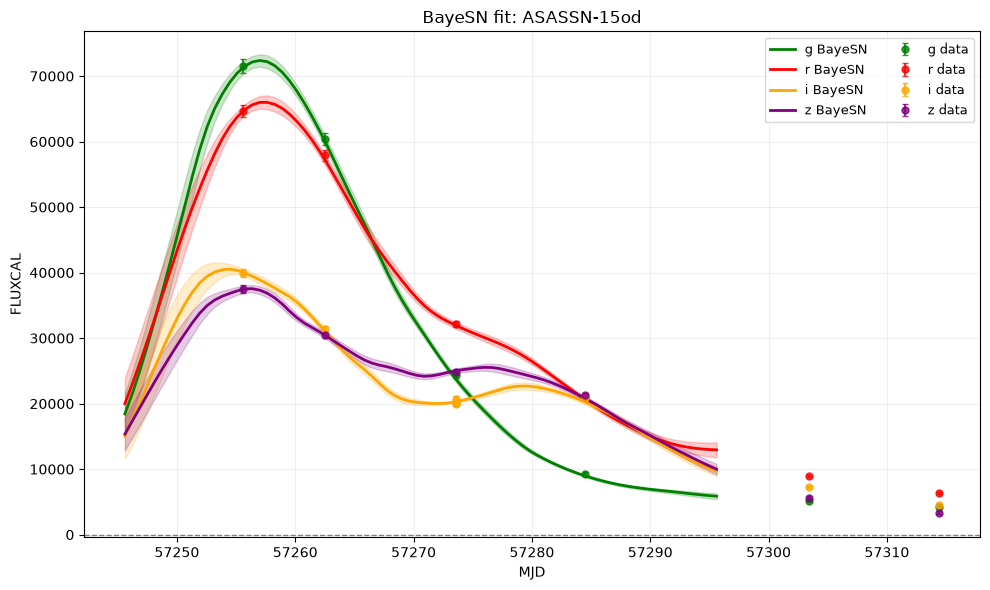

In [54]:
snid = "ASASSN-15od"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)

Task was destroyed but it is pending!
task: <Task pending name='Task-326' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/astropy/units/core.py:2423: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for b_sub, p_sub in zip(b._bases, b._powers):
Task was destroyed but it is pending!
task: <Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/jennakempster-taylor/m

Fitting PS15asb
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15asb.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:02<00:00,  7.99it/s, 63 steps of size 6.06e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:53<00:00,  9.40it/s, 63 steps of size 5.54e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.06      0.08      0.00      0.17    501.57      1.01
          Ds[0]     36.59      0.06     36.59     36.50     36.68    399.67      1.01
 eps_tform[0,0]     -0.56      0.87     -0.56     -2.03      0.82    963.92      1.00
 eps_tform[0,1]      1.02      0.77      1.00     -0.21      2.31    867.51      1.00
 eps_tform[0,2]     -0.03      0.86     -0.02     -1.59      1.27    999.53      1.00
 eps_tform[0,3]     -0.08      0.89     -0.03     -1.43      1.47   1061.51      1.00
 eps_tform[0,4]      1.09      0.72      1.11     -0.27      2.12    853.80      1.00
 eps_tform[0,5]     -0.16      0.77     -0.18     -1.34      1.16    840.71      1.00
 eps_tform[0,6]      0.95      0.76      0.93     -0.08      2.47    841.37      1.00
 eps_tform[0,7]     -0.83      0.69     -0.84     -1.90      0.38   1088.05      1.00
 eps_tform[0,8]     -1.45      0.76     -1.45     -2.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/it]


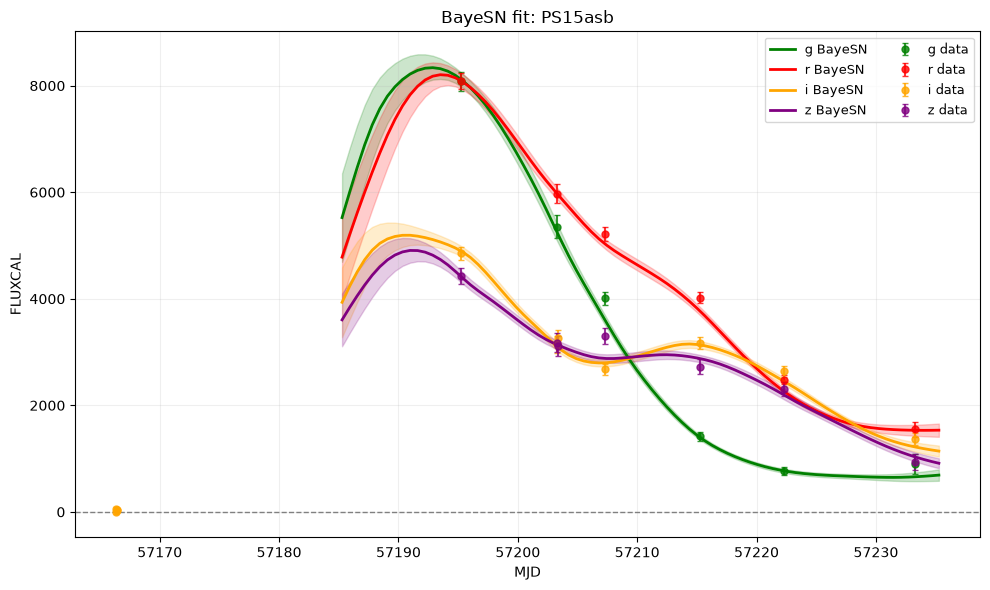

In [55]:
snid = "PS15asb"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



Fitting PS15mt
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15mt.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:54<00:00,  9.15it/s, 63 steps of size 6.71e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:47<00:00, 10.48it/s, 63 steps of size 7.38e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.07      0.05      0.06      0.00      0.13    139.17      1.03
          Ds[0]     37.55      0.05     37.55     37.47     37.64    195.65      1.03
 eps_tform[0,0]     -0.21      0.71     -0.20     -1.40      0.91    423.05      1.00
 eps_tform[0,1]     -0.11      0.41     -0.14     -0.75      0.61    801.39      1.00
 eps_tform[0,2]      1.07      0.54      1.08      0.22      1.98    542.95      1.00
 eps_tform[0,3]      0.80      0.76      0.82     -0.46      2.03    892.28      1.00
 eps_tform[0,4]     -0.86      0.67     -0.83     -1.92      0.22    587.89      1.00
 eps_tform[0,5]      0.04      0.71     -0.00     -1.11      1.09    139.69      1.04
 eps_tform[0,6]      0.21      0.65      0.21     -0.87      1.21    354.60      1.01
 eps_tform[0,7]     -1.52      0.63     -1.52     -2.52     -0.47    844.49      1.00
 eps_tform[0,8]     -0.15      0.76     -0.18     -1.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.14s/it]


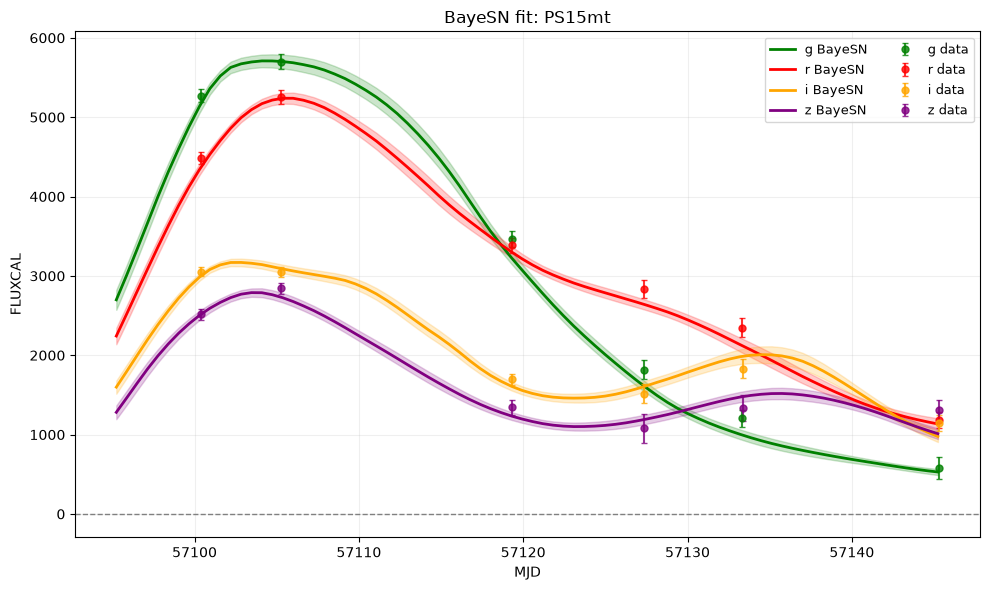

In [56]:
snid = "PS15mt"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



Fitting PS15adh
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15adh.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:27<00:00, 18.12it/s, 31 steps of size 1.78e-01. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:25<00:00, 19.33it/s, 31 steps of size 1.60e-01. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.05      0.00      0.13    756.93      1.00
          Ds[0]     38.27      0.08     38.28     38.15     38.40    469.69      1.00
 eps_tform[0,0]     -0.17      1.00     -0.20     -1.62      1.56   1691.95      1.00
 eps_tform[0,1]     -0.36      0.92     -0.39     -1.90      1.12   1540.03      1.00
 eps_tform[0,2]     -0.12      0.93     -0.12     -1.77      1.29   1398.58      1.00
 eps_tform[0,3]     -0.41      0.95     -0.35     -2.06      1.08   1382.27      1.00
 eps_tform[0,4]     -0.91      0.81     -0.93     -2.28      0.39   1123.38      1.00
 eps_tform[0,5]      0.05      0.89      0.04     -1.31      1.50   1225.61      1.00
 eps_tform[0,6]     -0.58      0.91     -0.57     -2.13      0.81   1062.54      1.00
 eps_tform[0,7]     -0.13      0.96     -0.11     -1.70      1.37   1140.67      1.00
 eps_tform[0,8]     -0.15      0.94     -0.15     -1.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.08s/it]


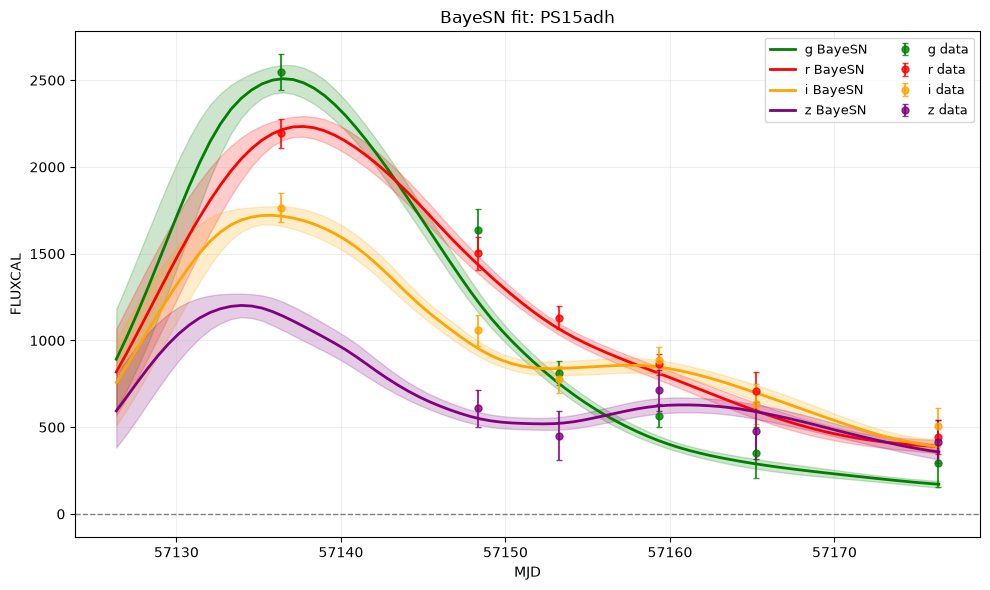

In [57]:
snid = "PS15adh"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



In [58]:
eps_keys = [
    key for key in samples
    if key.startswith("eps")
]

In [59]:
eps = np.asarray(samples["eps_tform"])
print(eps.shape)

(4, 250, 1, 24)


In [60]:
eps_flat = eps.reshape(-1, eps.shape[-1])

eps_median = np.median(
    eps_flat,
    axis=0,
)

In [61]:
max_abs_eps = np.max(
    np.abs(eps_median)
)

rms_eps = np.sqrt(
    np.mean(eps_median**2)
)

print("max |epsilon|:", max_abs_eps)
print("RMS epsilon:", rms_eps)

max |epsilon|: 0.9284813292724015
RMS epsilon: 0.34585497432922413


In [62]:
plt.scatter(
    coverage_df["n_observations"],
    fit_results["max_abs_eps"]
)

NameError: name 'fit_results' is not defined

In [63]:
eps = np.asarray(samples["eps_tform"])

print(eps.shape)
eps_flat = eps.reshape(-1, eps.shape[-1])

eps_q05 = np.percentile(eps_flat, 5, axis=0)
eps_med = np.percentile(eps_flat, 50, axis=0)
eps_q95 = np.percentile(eps_flat, 95, axis=0)

(4, 250, 1, 24)


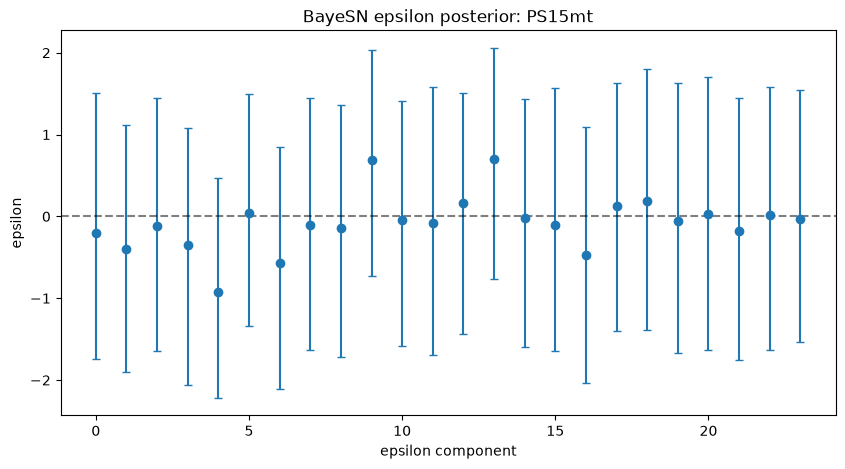

In [67]:
x = np.arange(len(eps_med))

plt.figure(figsize=(10, 5))

plt.errorbar(
    x,
    eps_med,
    yerr=[
        eps_med - eps_q05,
        eps_q95 - eps_med,
    ],
    fmt="o",
    capsize=3,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("epsilon component")
plt.ylabel("epsilon")
plt.title(f"BayeSN epsilon posterior: {'PS15mt'}")

plt.show()

### Two fit experiment 

In [72]:
snid = "ASASSN-15so"

sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

print(sn_file)
print(sn_file.exists())


/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_ASASSN-15so.txt
True


In [73]:
fixed_model = SEDmodel(load_model="T21_model")

fixed_samples, fixed_props = fixed_model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=False,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:23<00:00,  3.47it/s, 255 steps of size 2.38e-02. acc. p
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:08<00:00,  3.90it/s, 255 steps of size 3.85e-02. acc. p
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.10      0.05      0.10      0.02      0.18    204.89      1.04
          Ds[0]     32.78      0.04     32.78     32.72     32.86    246.22      1.03
 eps_tform[0,0]      0.38      0.58      0.37     -0.58      1.32    474.55      1.01
 eps_tform[0,1]      1.13      0.53      1.12      0.21      1.96    748.20      1.00
 eps_tform[0,2]      1.47      0.54      1.46      0.60      2.33    874.65      1.00
 eps_tform[0,3]      0.12      0.68      0.11     -0.97      1.29    431.96      1.01
 eps_tform[0,4]     -1.46      0.60     -1.44     -2.33     -0.47    157.83      1.05
 eps_tform[0,5]     -0.24      0.55     -0.22     -1.13      0.58    585.36      1.01
 eps_tform[0,6]     -0.37      0.55     -0.38     -1.34      0.40    244.85      1.03
 eps_tform[0,7]     -0.26      0.43     -0.26     -0.89      0.51    474.55      1.01
 eps_tform[0,8]      0.82      0.58      0.83     -0.

In [74]:
photoz_model = SEDmodel(load_model="T21_model")

photoz_samples, photoz_props = photoz_model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=jnp.arange(0, 1, 0.1),
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [04:54<00:00,  1.70it/s, 255 steps of size 2.13e-02. acc. p
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [04:37<00:00,  1.80it/s, 255 steps of size 2.36e-02. acc. p
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.06      0.00      0.14      3.97      1.42
          Ds[0]     32.93      0.21     32.83     32.76     33.30      2.06      5.73
 eps_tform[0,0]     -1.35      5.10      1.32    -10.41      2.31      2.02      9.54
 eps_tform[0,1]      1.40      0.54      1.31      0.59      2.29     13.44      1.10
 eps_tform[0,2]      1.54      0.53      1.58      0.61      2.33     62.02      1.03
 eps_tform[0,3]      0.95      0.91      0.86     -0.37      2.58      6.34      1.20
 eps_tform[0,4]     -0.34      1.25     -0.75     -1.79      1.95      2.36      2.49
 eps_tform[0,5]      5.07      8.23      0.54     -0.39     19.62      2.01     18.19
 eps_tform[0,6]     -0.41      0.56     -0.38     -1.30      0.49     48.77      1.06
 eps_tform[0,7]     -0.10      0.52     -0.07     -0.99      0.74     19.00      1.29
 eps_tform[0,8]      0.61      1.24      0.20     -0.

Fixed/input redshift: 0.0070224


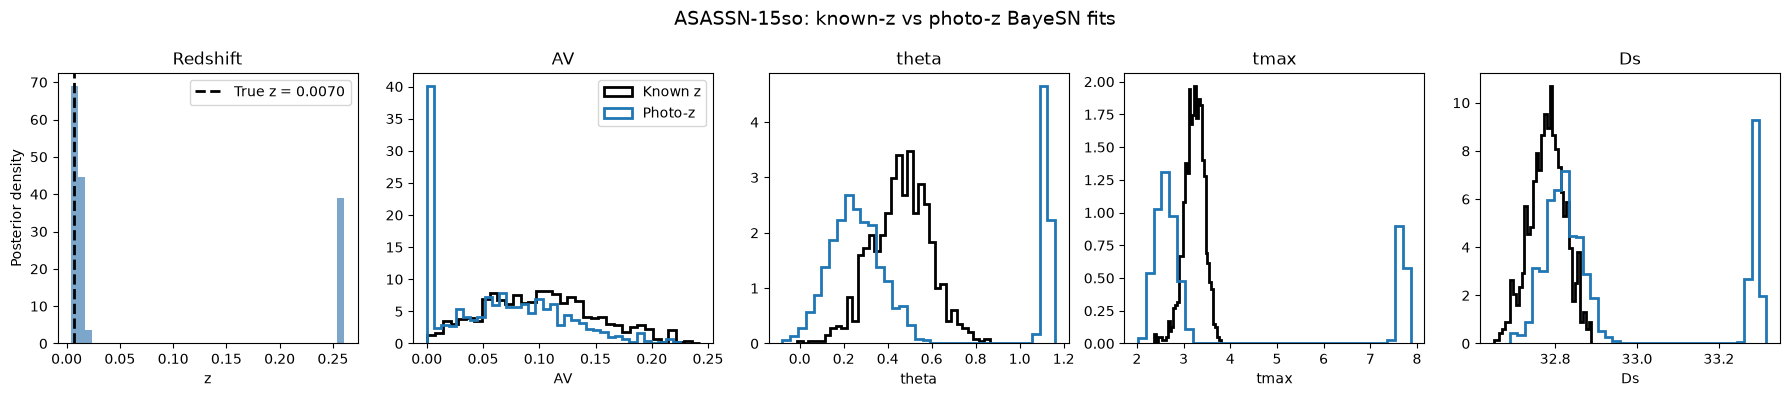

In [76]:
fixed_z = float(np.asarray(fixed_props[0]).squeeze())

print("Fixed/input redshift:", fixed_z)

params = ["AV", "theta", "tmax", "Ds"]

fig, axes = plt.subplots(
    1, len(params) + 1,
    figsize=(18, 4)
)

# -------------------------
# Redshift
# -------------------------
z_samples = np.asarray(photoz_samples["z"]).reshape(-1)

axes[0].hist(
    z_samples,
    bins=40,
    density=True,
    alpha=0.7,
    color="steelblue"
)

axes[0].axvline(
    fixed_z,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"True z = {fixed_z:.4f}"
)

axes[0].set_xlabel("z")
axes[0].set_ylabel("Posterior density")
axes[0].set_title("Redshift")
axes[0].legend()


# -------------------------
# Other parameters
# -------------------------
for ax, key in zip(axes[1:], params):

    fixed = np.asarray(
        fixed_samples[key]
    ).reshape(-1)

    photoz = np.asarray(
        photoz_samples[key]
    ).reshape(-1)

    ax.hist(
        fixed,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color="black",
        label="Known z"
    )

    ax.hist(
        photoz,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color="tab:blue",
        label="Photo-z"
    )

    ax.set_xlabel(key)
    ax.set_title(key)

axes[1].legend()

fig.suptitle(
    f"{snid}: known-z vs photo-z BayeSN fits",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [77]:
params = ["AV", "theta", "tmax", "Ds"]

rows = []

for key in params:

    fixed = np.asarray(
        fixed_samples[key]
    ).reshape(-1)

    photoz = np.asarray(
        photoz_samples[key]
    ).reshape(-1)

    f16, f50, f84 = np.percentile(
        fixed,
        [16, 50, 84]
    )

    p16, p50, p84 = np.percentile(
        photoz,
        [16, 50, 84]
    )

    rows.append({
        "parameter": key,
        "fixed_z_median": f50,
        "fixed_z_sigma": (f84 - f16) / 2,
        "photo_z_median": p50,
        "photo_z_sigma": (p84 - p16) / 2,
        "median_shift": p50 - f50,
        "uncertainty_ratio":
            ((p84 - p16) / 2)
            /
            ((f84 - f16) / 2)
    })

comparison = pd.DataFrame(rows)

comparison

,parameter,fixed_z_median,fixed_z_sigma,photo_z_median,photo_z_sigma,median_shift,uncertainty_ratio
0,AV,0.099814,0.050936,0.062561,0.059024,-0.037253,1.158775
1,theta,0.463918,0.129659,0.302751,0.478686,-0.161167,3.691895
2,tmax,3.235199,0.200952,2.705869,2.608298,-0.529330,12.979738
3,Ds,32.782696,0.044493,32.834904,0.251454,0.052209,5.651600


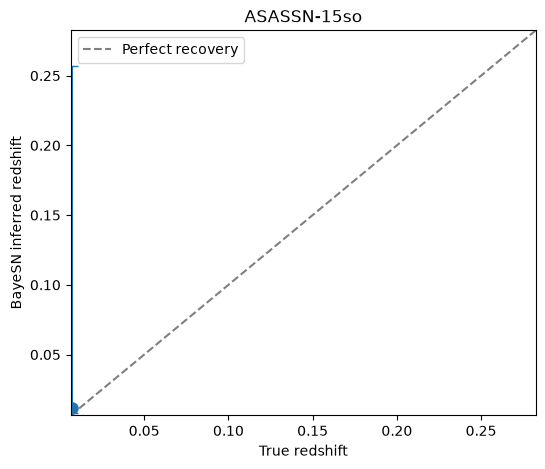

In [78]:
z_samples = np.asarray(
    photoz_samples["z"]
).reshape(-1)

z16, z50, z84 = np.percentile(
    z_samples,
    [16, 50, 84]
)

plt.figure(figsize=(6, 5))

plt.errorbar(
    fixed_z,
    z50,
    yerr=[
        [z50 - z16],
        [z84 - z50]
    ],
    fmt="o",
    markersize=8,
    capsize=4
)

lims = [
    min(fixed_z, z16) * 0.9,
    max(fixed_z, z84) * 1.1
]

plt.plot(
    lims,
    lims,
    "--",
    color="grey",
    label="Perfect recovery"
)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True redshift")
plt.ylabel("BayeSN inferred redshift")
plt.title(snid)
plt.legend()

plt.show()

In [82]:
def plot_fit_on_axis(
    snid,
    samples,
    sn_props,
    ax,
    title,
    num_samples=500,
):
    # Fresh model for plotting
    plot_model = SEDmodel(load_model="T21_model")

    # Copy samples so we do not modify original chains
    plot_samples = {
        key: np.asarray(value)
        for key, value in samples.items()
    }

    # Needed for current photo-z branch
    if "mu" not in plot_samples:
        plot_samples["mu"] = plot_samples["Ds"]

    if "delM" not in plot_samples:
        plot_samples["delM"] = np.zeros_like(
            plot_samples["Ds"]
        )

    # Read the Foundation photometry
    meta, lc = read_foundation_sn(snid)

    peak_mjd = float(meta["SEARCH_PEAKMJD"])

    # Phase grid used for the BayeSN model
    phase = np.linspace(-10, 40, 150)

    bands = [
        "g_PS1",
        "r_PS1",
        "i_PS1",
        "z_PS1",
    ]

    z, ebv_mw = sn_props

    flux_grid = plot_model.get_flux_from_chains(
        phase,
        bands,
        plot_samples,
        z,
        ebv_mw,
        mag=False,
        num_samples=num_samples,
    )

    # shape roughly:
    # chain x samples x bands x time
    mean_flux = flux_grid.mean(axis=(0, 1))
    std_flux = flux_grid.std(axis=(0, 1))

    mjd_grid = phase + peak_mjd

    colors = {
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
    }

    for i, band in enumerate(["g", "r", "i", "z"]):

        band_data = lc[
            lc["FLT"] == band
        ]

        # Observed data
        ax.errorbar(
            band_data["MJD"],
            band_data["FLUXCAL"],
            yerr=band_data["FLUXCALERR"],
            fmt="o",
            markersize=4,
            capsize=2,
            color=colors[band],
            alpha=0.7,
        )

        # BayeSN posterior mean
        ax.plot(
            mjd_grid,
            mean_flux[i],
            color=colors[band],
            linewidth=2,
            label=band,
        )

        # Approx posterior spread
        ax.fill_between(
            mjd_grid,
            mean_flux[i] - std_flux[i],
            mean_flux[i] + std_flux[i],
            color=colors[band],
            alpha=0.15,
        )

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(title)
    ax.set_xlabel("MJD")
    ax.grid(alpha=0.2)

    return ax

In [89]:

def plot_fit_comparison(
    snid,
    fixed_samples,
    fixed_props,
    photoz_samples,
    photoz_props,
    num_samples=100,
):

    # Same time grid as your original plotting code
    t = np.linspace(-10, 40, 200)

    bands = [
        "g_PS1",
        "r_PS1",
        "i_PS1",
        "z_PS1",
    ]

    short_bands = ["g", "r", "i", "z"]

    colors = {
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
    }

    # --------------------------------------------------
    # Observed Foundation light curve
    # --------------------------------------------------

    lc = detections_df[
        detections_df["SNID"] == snid
    ].copy()

    peak_mjd = float(
        metadata_df.loc[
            metadata_df["SNID"] == snid,
            "SEARCH_PEAKMJD",
        ].iloc[0]
    )

    plot_t = t + peak_mjd


    # --------------------------------------------------
    # FIXED-Z MODEL
    # --------------------------------------------------

    fixed_model = SEDmodel(
        load_model="T21_model"
    )

    fixed_z, fixed_ebv = fixed_props

    fixed_flux = fixed_model.get_flux_from_chains(
        t,
        bands,
        fixed_samples,
        fixed_z,
        fixed_ebv,
        mag=False,
        num_samples=num_samples,
    )

    fixed_mean = fixed_flux.mean(axis=(0, 1))
    fixed_std = fixed_flux.std(axis=(0, 1))


    # --------------------------------------------------
    # PHOTO-Z MODEL
    # --------------------------------------------------

    photoz_model = SEDmodel(
        load_model="T21_model"
    )

    # make a copy so don't alter original chains
    photo_samples_plot = {
        k: np.asarray(v)
        for k, v in photoz_samples.items()
    }

    # Needed by the photo-z reconstruction code
    if "mu" not in photo_samples_plot:
        photo_samples_plot["mu"] = (
            photo_samples_plot["Ds"]
        )

    if "delM" not in photo_samples_plot:
        photo_samples_plot["delM"] = np.zeros_like(
            photo_samples_plot["Ds"]
        )

    photoz_z, photoz_ebv = photoz_props

    photoz_flux = photoz_model.get_flux_from_chains(
        t,
        bands,
        photo_samples_plot,
        photoz_z,
        photoz_ebv,
        mag=False,
        num_samples=num_samples,
    )

    photoz_mean = photoz_flux.mean(axis=(0, 1))
    photoz_std = photoz_flux.std(axis=(0, 1))


    # --------------------------------------------------
    # REDSHIFT VALUES FOR TITLES
    # --------------------------------------------------

    true_z = float(
        np.asarray(fixed_props[0]).squeeze()
    )

    z_samples = np.asarray(
        photoz_samples["z"]
    ).reshape(-1)

    z16, z50, z84 = np.percentile(
        z_samples,
        [16, 50, 84],
    )


    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharex=True,
        sharey=True,
    )

    for b_ind, band in enumerate(short_bands):

        band_data = lc[
            lc["FLT"] == band
        ]

        # Same observed data on BOTH panels
        for ax in axes:
            ax.errorbar(
                band_data["MJD"],
                band_data["FLUXCAL"],
                yerr=band_data["FLUXCALERR"],
                fmt="o",
                markersize=4,
                capsize=2,
                color=colors[band],
                alpha=0.65,
            )

        # Fixed-z reconstruction
        axes[0].plot(
            plot_t,
            fixed_mean[b_ind],
            color=colors[band],
            linewidth=2,
            label=band,
        )

        axes[0].fill_between(
            plot_t,
            fixed_mean[b_ind] - fixed_std[b_ind],
            fixed_mean[b_ind] + fixed_std[b_ind],
            color=colors[band],
            alpha=0.15,
        )

        # Photo-z reconstruction
        axes[1].plot(
            plot_t,
            photoz_mean[b_ind],
            color=colors[band],
            linewidth=2,
            label=band,
        )
        

        axes[1].fill_between(
            plot_t,
            photoz_mean[b_ind] - photoz_std[b_ind],
            photoz_mean[b_ind] + photoz_std[b_ind],
            color=colors[band],
            alpha=0.15,
        )


    # --------------------------------------------------
    # FORMATTING
    # --------------------------------------------------

    axes[0].set_title(
        f"Fixed redshift\n"
        f"z = {true_z:.4f}"
    )


    axes[1].set_title(
        "Photo-z\n"
        f"median z = {z50:.4f}, "
        f"68% CI = [{z16:.4f}, {z84:.4f}]"
)

    for ax in axes:
        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1,
        )

        ax.set_xlabel("MJD")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("FLUXCAL")

    axes[1].legend(
        title="Filter",
        loc="best",
    )

    fig.suptitle(
        f"{snid}: BayeSN fixed-z vs photo-z",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.88s/it]


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.93s/it]


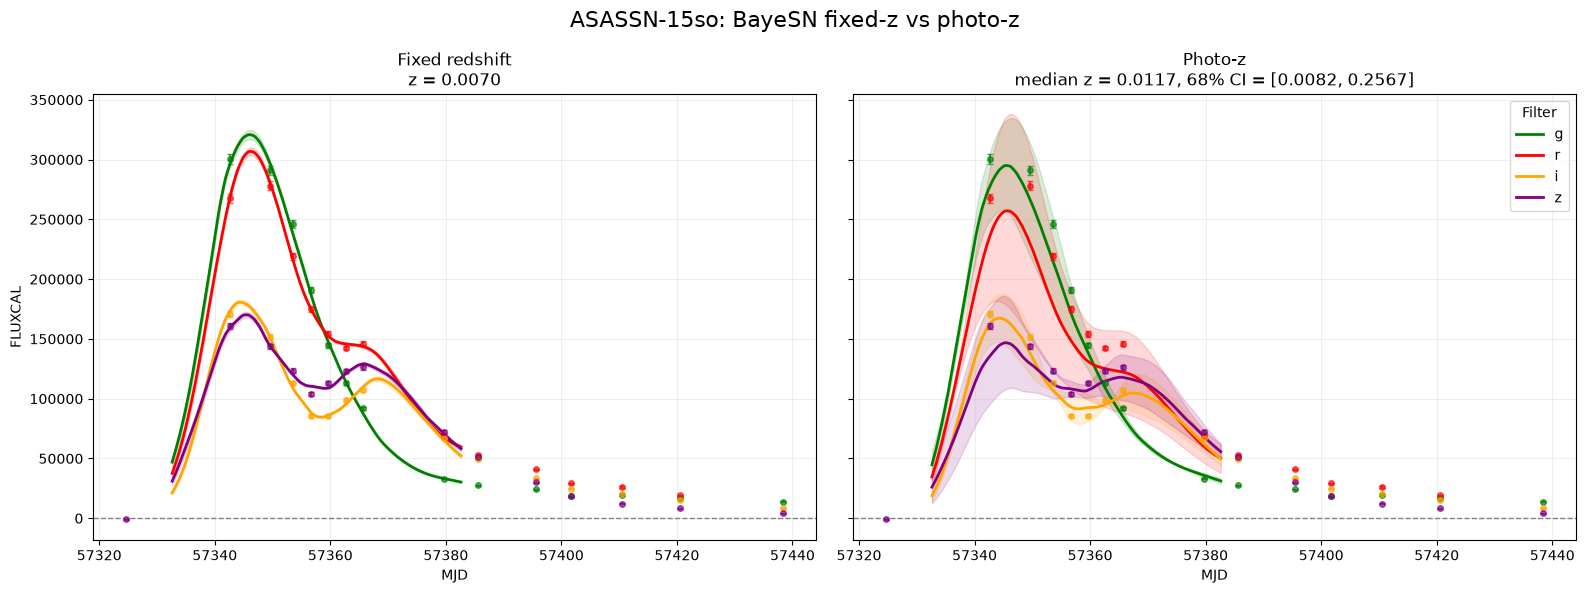

In [90]:
plot_fit_comparison(
    snid,
    fixed_samples,
    fixed_props,
    photoz_samples,
    photoz_props,
    num_samples=100,
)

### On PS15asb

In [91]:
snid = "PS15asb"

sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

print(sn_file)
print(sn_file.exists())


/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15asb.txt
True


In [92]:
fixed_model = SEDmodel(load_model="T21_model")

fixed_samples, fixed_props = fixed_model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=False,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:05<00:00,  7.62it/s, 63 steps of size 6.06e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:59<00:00,  8.43it/s, 63 steps of size 5.54e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.06      0.08      0.00      0.17    501.57      1.01
          Ds[0]     36.59      0.06     36.59     36.50     36.68    399.67      1.01
 eps_tform[0,0]     -0.56      0.87     -0.56     -2.03      0.82    963.92      1.00
 eps_tform[0,1]      1.02      0.77      1.00     -0.21      2.31    867.51      1.00
 eps_tform[0,2]     -0.03      0.86     -0.02     -1.59      1.27    999.53      1.00
 eps_tform[0,3]     -0.08      0.89     -0.03     -1.43      1.47   1061.51      1.00
 eps_tform[0,4]      1.09      0.72      1.11     -0.27      2.12    853.80      1.00
 eps_tform[0,5]     -0.16      0.77     -0.18     -1.34      1.16    840.71      1.00
 eps_tform[0,6]      0.95      0.76      0.93     -0.08      2.47    841.37      1.00
 eps_tform[0,7]     -0.83      0.69     -0.84     -1.90      0.38   1088.05      1.00
 eps_tform[0,8]     -1.45      0.76     -1.45     -2.

In [93]:
photoz_model = SEDmodel(load_model="T21_model")

photoz_samples, photoz_props = photoz_model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=jnp.arange(0, 1, 0.1),
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:17<00:00,  3.63it/s, 63 steps of size 9.72e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:41<00:00,  4.94it/s, 63 steps of size 5.91e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.05      0.00      0.12    306.18      1.03
          Ds[0]     36.84      0.26     36.80     36.51     37.16      2.09      4.88
 eps_tform[0,0]     -1.43      1.31     -1.40     -3.38      0.72      3.07      1.65
 eps_tform[0,1]      0.04      1.22      0.03     -2.03      1.87      3.25      1.57
 eps_tform[0,2]      0.11      0.86      0.12     -1.19      1.63   1170.78      1.00
 eps_tform[0,3]      0.47      1.05      0.41     -1.25      2.08      8.60      1.14
 eps_tform[0,4]     -0.70      2.01     -1.00     -3.30      2.24      2.23      3.00
 eps_tform[0,5]      2.27      2.60      2.09     -1.29      5.70      2.17      3.44
 eps_tform[0,6]     -0.57      1.48     -0.54     -2.88      1.61      2.76      1.85
 eps_tform[0,7]     -0.65      0.92     -0.62     -2.26      0.70     14.49      1.08
 eps_tform[0,8]     -2.06      0.99     -2.07     -3.

Fixed/input redshift: 0.04863


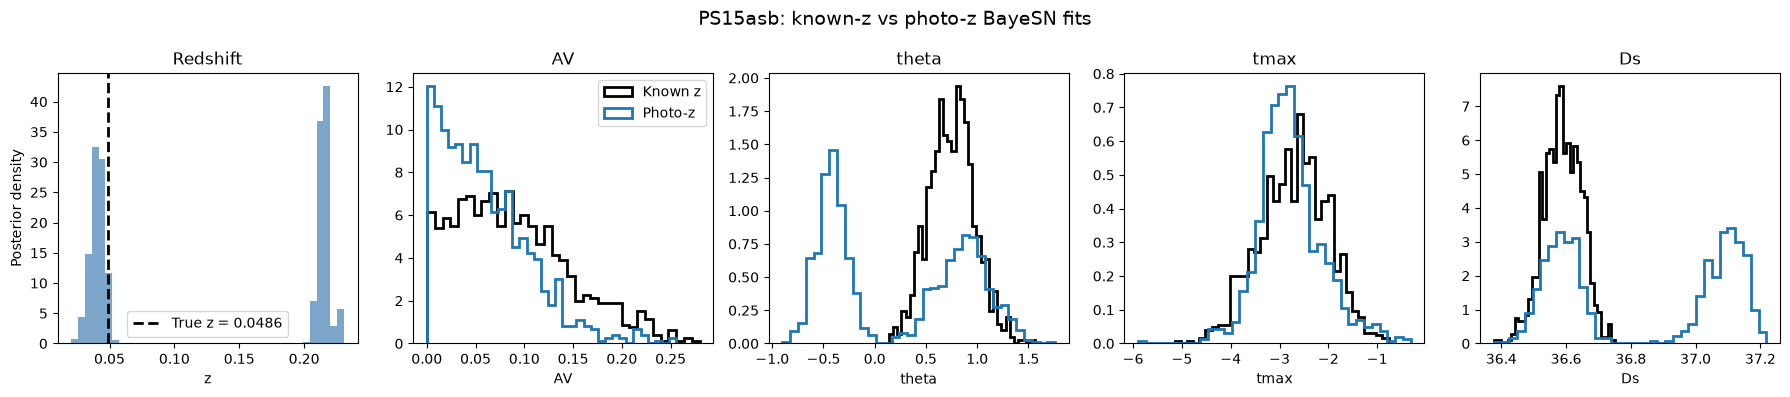

In [94]:
fixed_z = float(np.asarray(fixed_props[0]).squeeze())

print("Fixed/input redshift:", fixed_z)

params = ["AV", "theta", "tmax", "Ds"]

fig, axes = plt.subplots(
    1, len(params) + 1,
    figsize=(18, 4)
)

# -------------------------
# Redshift
# -------------------------
z_samples = np.asarray(photoz_samples["z"]).reshape(-1)

axes[0].hist(
    z_samples,
    bins=40,
    density=True,
    alpha=0.7,
    color="steelblue"
)

axes[0].axvline(
    fixed_z,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"True z = {fixed_z:.4f}"
)

axes[0].set_xlabel("z")
axes[0].set_ylabel("Posterior density")
axes[0].set_title("Redshift")
axes[0].legend()


# -------------------------
# Other parameters
# -------------------------
for ax, key in zip(axes[1:], params):

    fixed = np.asarray(
        fixed_samples[key]
    ).reshape(-1)

    photoz = np.asarray(
        photoz_samples[key]
    ).reshape(-1)

    ax.hist(
        fixed,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color="black",
        label="Known z"
    )

    ax.hist(
        photoz,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color="tab:blue",
        label="Photo-z"
    )

    ax.set_xlabel(key)
    ax.set_title(key)

axes[1].legend()

fig.suptitle(
    f"{snid}: known-z vs photo-z BayeSN fits",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [95]:
params = ["AV", "theta", "tmax", "Ds"]

rows = []

for key in params:

    fixed = np.asarray(
        fixed_samples[key]
    ).reshape(-1)

    photoz = np.asarray(
        photoz_samples[key]
    ).reshape(-1)

    f16, f50, f84 = np.percentile(
        fixed,
        [16, 50, 84]
    )

    p16, p50, p84 = np.percentile(
        photoz,
        [16, 50, 84]
    )

    rows.append({
        "parameter": key,
        "fixed_z_median": f50,
        "fixed_z_sigma": (f84 - f16) / 2,
        "photo_z_median": p50,
        "photo_z_sigma": (p84 - p16) / 2,
        "median_shift": p50 - f50,
        "uncertainty_ratio":
            ((p84 - p16) / 2)
            /
            ((f84 - f16) / 2)
    })

comparison = pd.DataFrame(rows)

comparison

,parameter,fixed_z_median,fixed_z_sigma,photo_z_median,photo_z_sigma,median_shift,uncertainty_ratio
0,AV,0.080746,0.059038,0.050444,0.044598,-0.030302,0.755420
1,theta,0.750687,0.217853,0.082668,0.736736,-0.668019,3.381800
2,tmax,-2.667933,0.725589,-2.847720,0.574405,-0.179787,0.791640
3,Ds,36.587131,0.058615,36.799981,0.285544,0.212850,4.871518


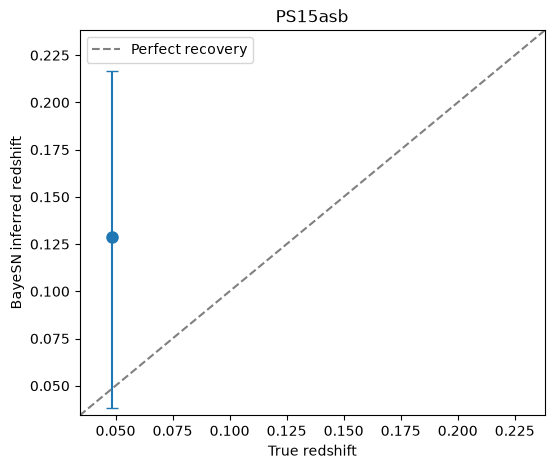

In [96]:
z_samples = np.asarray(
    photoz_samples["z"]
).reshape(-1)

z16, z50, z84 = np.percentile(
    z_samples,
    [16, 50, 84]
)

plt.figure(figsize=(6, 5))

plt.errorbar(
    fixed_z,
    z50,
    yerr=[
        [z50 - z16],
        [z84 - z50]
    ],
    fmt="o",
    markersize=8,
    capsize=4
)

lims = [
    min(fixed_z, z16) * 0.9,
    max(fixed_z, z84) * 1.1
]

plt.plot(
    lims,
    lims,
    "--",
    color="grey",
    label="Perfect recovery"
)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True redshift")
plt.ylabel("BayeSN inferred redshift")
plt.title(snid)
plt.legend()

plt.show()

In [97]:

def plot_fit_comparison(
    snid,
    fixed_samples,
    fixed_props,
    photoz_samples,
    photoz_props,
    num_samples=100,
):

    # Same time grid as your original plotting code
    t = np.linspace(-10, 40, 200)

    bands = [
        "g_PS1",
        "r_PS1",
        "i_PS1",
        "z_PS1",
    ]

    short_bands = ["g", "r", "i", "z"]

    colors = {
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
    }

    # --------------------------------------------------
    # Observed Foundation light curve
    # --------------------------------------------------

    lc = detections_df[
        detections_df["SNID"] == snid
    ].copy()

    peak_mjd = float(
        metadata_df.loc[
            metadata_df["SNID"] == snid,
            "SEARCH_PEAKMJD",
        ].iloc[0]
    )

    plot_t = t + peak_mjd


    # --------------------------------------------------
    # FIXED-Z MODEL
    # --------------------------------------------------

    fixed_model = SEDmodel(
        load_model="T21_model"
    )

    fixed_z, fixed_ebv = fixed_props

    fixed_flux = fixed_model.get_flux_from_chains(
        t,
        bands,
        fixed_samples,
        fixed_z,
        fixed_ebv,
        mag=False,
        num_samples=num_samples,
    )

    fixed_mean = fixed_flux.mean(axis=(0, 1))
    fixed_std = fixed_flux.std(axis=(0, 1))


    # --------------------------------------------------
    # PHOTO-Z MODEL
    # --------------------------------------------------

    photoz_model = SEDmodel(
        load_model="T21_model"
    )

    # make a copy so we don't alter your original chains
    photo_samples_plot = {
        k: np.asarray(v)
        for k, v in photoz_samples.items()
    }

    # Needed by the photo-z reconstruction code
    if "mu" not in photo_samples_plot:
        photo_samples_plot["mu"] = (
            photo_samples_plot["Ds"]
        )

    if "delM" not in photo_samples_plot:
        photo_samples_plot["delM"] = np.zeros_like(
            photo_samples_plot["Ds"]
        )

    photoz_z, photoz_ebv = photoz_props

    photoz_flux = photoz_model.get_flux_from_chains(
        t,
        bands,
        photo_samples_plot,
        photoz_z,
        photoz_ebv,
        mag=False,
        num_samples=num_samples,
    )

    photoz_mean = photoz_flux.mean(axis=(0, 1))
    photoz_std = photoz_flux.std(axis=(0, 1))


    # --------------------------------------------------
    # REDSHIFT VALUES FOR TITLES
    # --------------------------------------------------

    true_z = float(
        np.asarray(fixed_props[0]).squeeze()
    )

    z_samples = np.asarray(
        photoz_samples["z"]
    ).reshape(-1)

    z16, z50, z84 = np.percentile(
        z_samples,
        [16, 50, 84],
    )


    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharex=True,
        sharey=True,
    )

    for b_ind, band in enumerate(short_bands):

        band_data = lc[
            lc["FLT"] == band
        ]

        # Same observed data on BOTH panels
        for ax in axes:
            ax.errorbar(
                band_data["MJD"],
                band_data["FLUXCAL"],
                yerr=band_data["FLUXCALERR"],
                fmt="o",
                markersize=4,
                capsize=2,
                color=colors[band],
                alpha=0.65,
            )

        # Fixed-z reconstruction
        axes[0].plot(
            plot_t,
            fixed_mean[b_ind],
            color=colors[band],
            linewidth=2,
            label=band,
        )

        axes[0].fill_between(
            plot_t,
            fixed_mean[b_ind] - fixed_std[b_ind],
            fixed_mean[b_ind] + fixed_std[b_ind],
            color=colors[band],
            alpha=0.15,
        )

        # Photo-z reconstruction
        axes[1].plot(
            plot_t,
            photoz_mean[b_ind],
            color=colors[band],
            linewidth=2,
            label=band,
        )
        

        axes[1].fill_between(
            plot_t,
            photoz_mean[b_ind] - photoz_std[b_ind],
            photoz_mean[b_ind] + photoz_std[b_ind],
            color=colors[band],
            alpha=0.15,
        )


    # --------------------------------------------------
    # FORMATTING
    # --------------------------------------------------

    axes[0].set_title(
        f"Fixed redshift\n"
        f"z = {true_z:.4f}"
    )


    axes[1].set_title(
        "Photo-z\n"
        f"median z = {z50:.4f}, "
        f"68% CI = [{z16:.4f}, {z84:.4f}]"
)

    for ax in axes:
        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1,
        )

        ax.set_xlabel("MJD")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("FLUXCAL")

    axes[1].legend(
        title="Filter",
        loc="best",
    )

    fig.suptitle(
        f"{snid}: BayeSN fixed-z vs photo-z",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.16s/it]


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.69s/it]


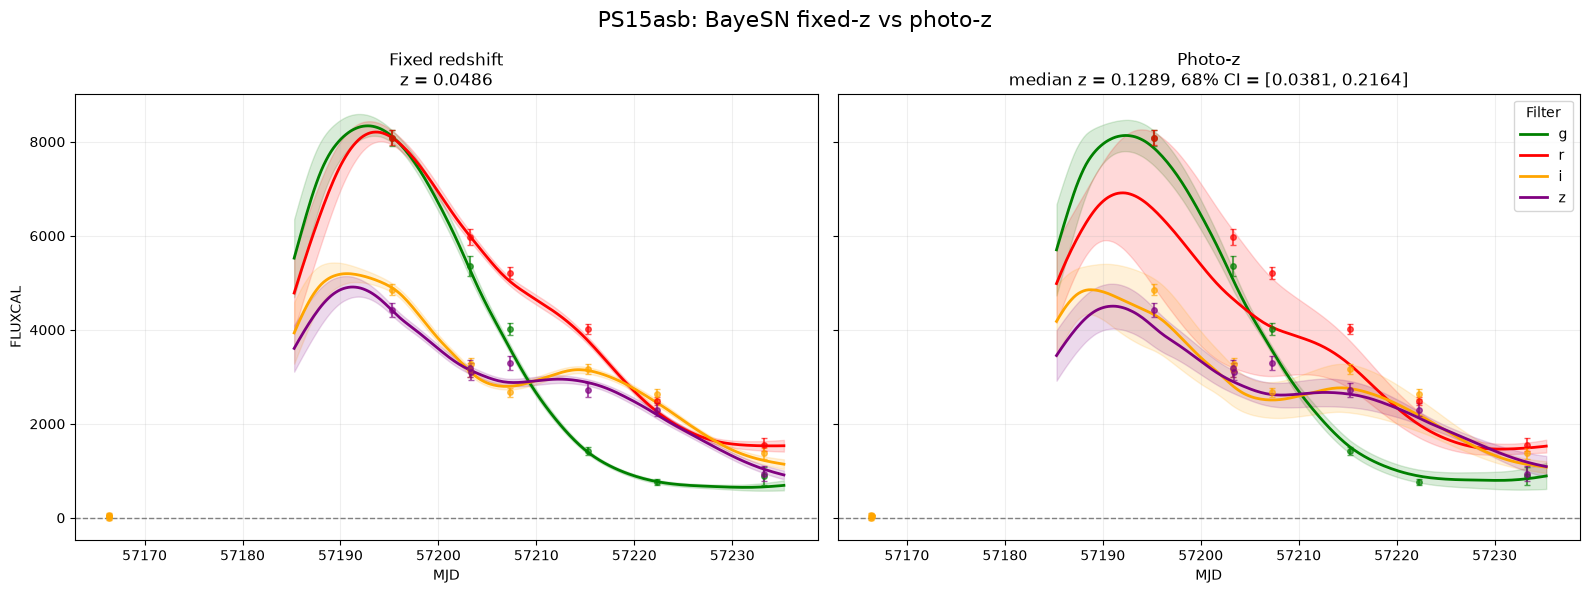

In [98]:
plot_fit_comparison(
    snid,
    fixed_samples,
    fixed_props,
    photoz_samples,
    photoz_props,
    num_samples=100,
)

### Comparison of z distributions 

In [99]:
# broad
zq_broad = jnp.arange(0, 1, 0.1)

# narrower low-z distribution
zq_low = jnp.linspace(0.0, 0.15, 10)

# intermediate
zq_mid = jnp.linspace(0.0, 0.30, 10)

In [100]:
model_broad = SEDmodel(load_model="T21_model")

samples_broad, props_broad = model_broad.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [03:13<00:00,  2.59it/s, 63 steps of size 9.72e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [03:02<00:00,  2.74it/s, 63 steps of size 5.91e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.05      0.00      0.12    306.18      1.03
          Ds[0]     36.84      0.26     36.80     36.51     37.16      2.09      4.88
 eps_tform[0,0]     -1.43      1.31     -1.40     -3.38      0.72      3.07      1.65
 eps_tform[0,1]      0.04      1.22      0.03     -2.03      1.87      3.25      1.57
 eps_tform[0,2]      0.11      0.86      0.12     -1.19      1.63   1170.78      1.00
 eps_tform[0,3]      0.47      1.05      0.41     -1.25      2.08      8.60      1.14
 eps_tform[0,4]     -0.70      2.01     -1.00     -3.30      2.24      2.23      3.00
 eps_tform[0,5]      2.27      2.60      2.09     -1.29      5.70      2.17      3.44
 eps_tform[0,6]     -0.57      1.48     -0.54     -2.88      1.61      2.76      1.85
 eps_tform[0,7]     -0.65      0.92     -0.62     -2.26      0.70     14.49      1.08
 eps_tform[0,8]     -2.06      0.99     -2.07     -3.

In [101]:
model_low = SEDmodel(load_model="T21_model")

samples_low, props_low = model_low.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_low,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:53<00:00,  4.41it/s, 63 steps of size 7.42e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:29<00:00,  5.62it/s, 63 steps of size 9.52e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.15      0.14      0.09      0.00      0.39      2.32      2.63
          Ds[0]     36.58      0.06     36.58     36.48     36.68    397.94      1.01
 eps_tform[0,0]     -0.97      1.21     -0.77     -3.06      0.85      3.47      1.50
 eps_tform[0,1]      0.89      0.82      0.88     -0.57      2.13    880.75      1.00
 eps_tform[0,2]     -0.15      0.93     -0.11     -1.67      1.32      8.91      1.13
 eps_tform[0,3]      0.11      0.99      0.06     -1.38      1.86     27.68      1.05
 eps_tform[0,4]      0.26      1.79      0.88     -3.03      2.38      2.31      2.63
 eps_tform[0,5]      0.50      1.51      0.11     -1.31      3.42      2.59      2.02
 eps_tform[0,6]      0.81      0.82      0.82     -0.49      2.15     19.11      1.08
 eps_tform[0,7]     -1.13      1.55     -0.66     -3.89      0.94      2.53      2.11
 eps_tform[0,8]     -2.01      1.40     -1.65     -4.

In [103]:
model_mid = SEDmodel(load_model="T21_model")

samples_mid, props_mid = model_mid.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_mid,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:03<00:00,  4.03it/s, 63 steps of size 6.10e-02. acc. prob
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:28<00:00,  5.67it/s, 63 steps of size 8.96e-02. acc. prob
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.22      0.16      0.21      0.00      0.43      2.37      2.48
          Ds[0]     36.58      0.07     36.58     36.46     36.69    520.27      1.00
 eps_tform[0,0]     -1.47      1.32     -1.44     -3.48      0.70      3.18      1.59
 eps_tform[0,1]      0.84      0.84      0.87     -0.50      2.24    607.59      1.02
 eps_tform[0,2]     -0.39      0.97     -0.37     -2.00      1.23      7.17      1.17
 eps_tform[0,3]      0.33      1.02      0.31     -1.21      2.14     14.87      1.08
 eps_tform[0,4]     -0.68      1.99     -0.80     -3.30      2.18      2.23      3.02
 eps_tform[0,5]      1.24      1.66      1.29     -1.08      3.86      2.49      2.17
 eps_tform[0,6]      0.95      0.82      0.95     -0.33      2.37     19.97      1.07
 eps_tform[0,7]     -1.88      1.73     -1.85     -4.44      0.68      2.47      2.20
 eps_tform[0,8]     -2.72      1.56     -2.72     -4.

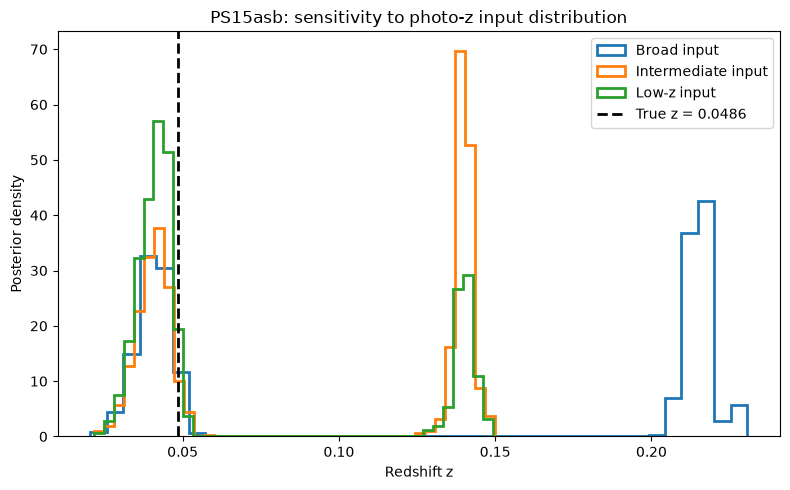

In [104]:
z_broad = np.asarray(samples_broad["z"]).reshape(-1)
z_low   = np.asarray(samples_low["z"]).reshape(-1)
z_mid   = np.asarray(samples_mid["z"]).reshape(-1)

plt.figure(figsize=(8, 5))

plt.hist(
    z_broad,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Broad input",
)

plt.hist(
    z_mid,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Intermediate input",
)

plt.hist(
    z_low,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Low-z input",
)

plt.axvline(
    fixed_z,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"True z = {fixed_z:.4f}",
)

plt.xlabel("Redshift z")
plt.ylabel("Posterior density")
plt.title(f"{snid}: sensitivity to photo-z input distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [105]:
for name, zvals in {
    "broad": z_broad,
    "mid": z_mid,
    "low": z_low,
}.items():

    q16, q50, q84 = np.percentile(
        zvals,
        [16, 50, 84],
    )

    print(
        f"{name:8s}: "
        f"{q50:.4f} "
        f"[-{q50-q16:.4f}, +{q84-q50:.4f}]"
    )

broad   : 0.1289 [-0.0908, +0.0875]
mid     : 0.0914 [-0.0534, +0.0497]
low     : 0.0437 [-0.0071, +0.0951]


### Diagnostic corner plots

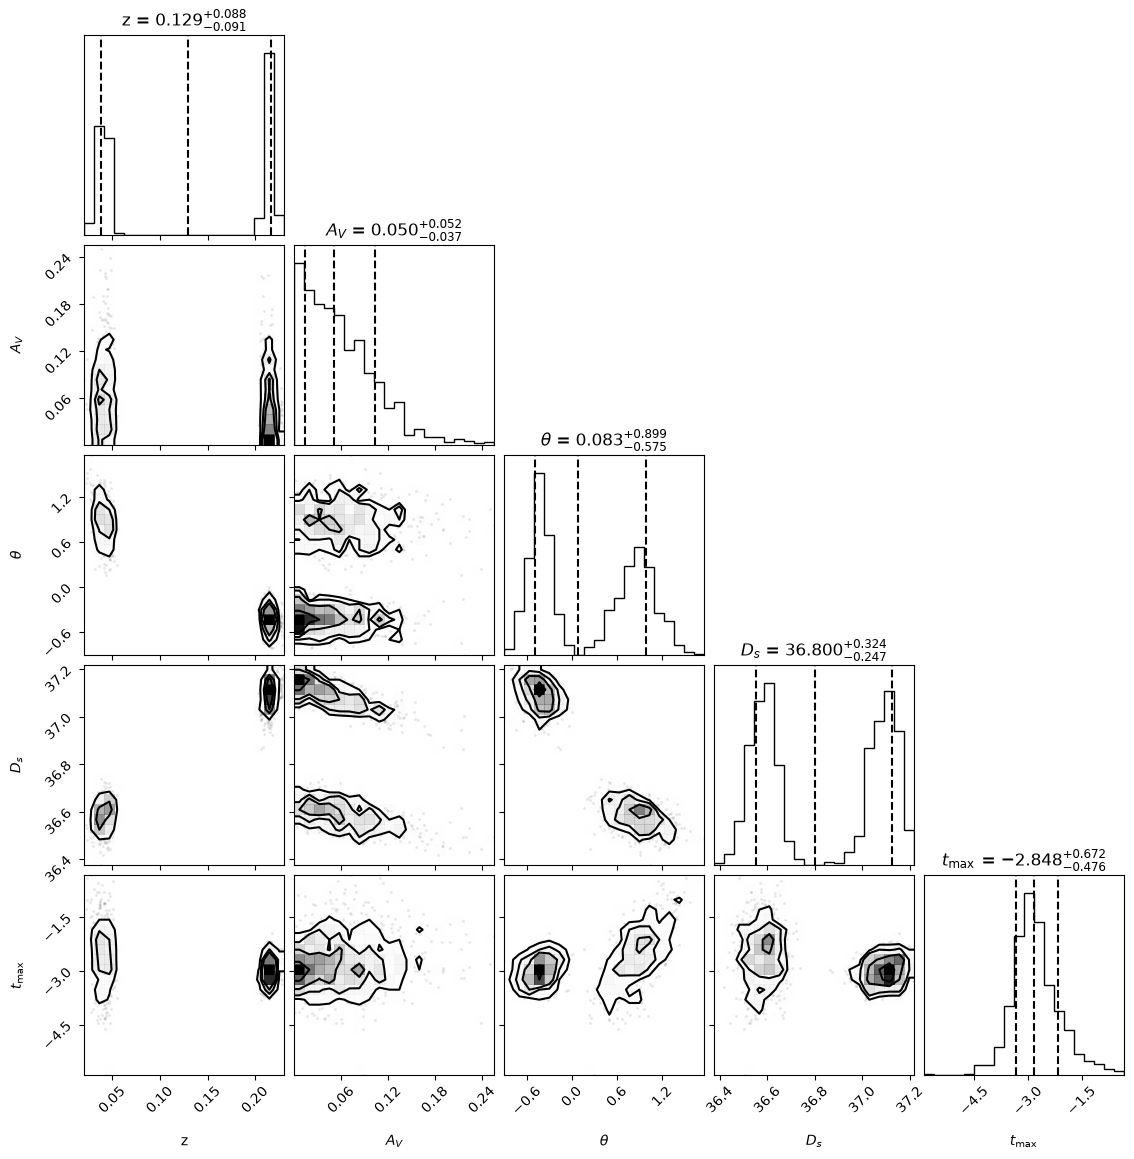

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import corner

keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_broad[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)

plt.show()

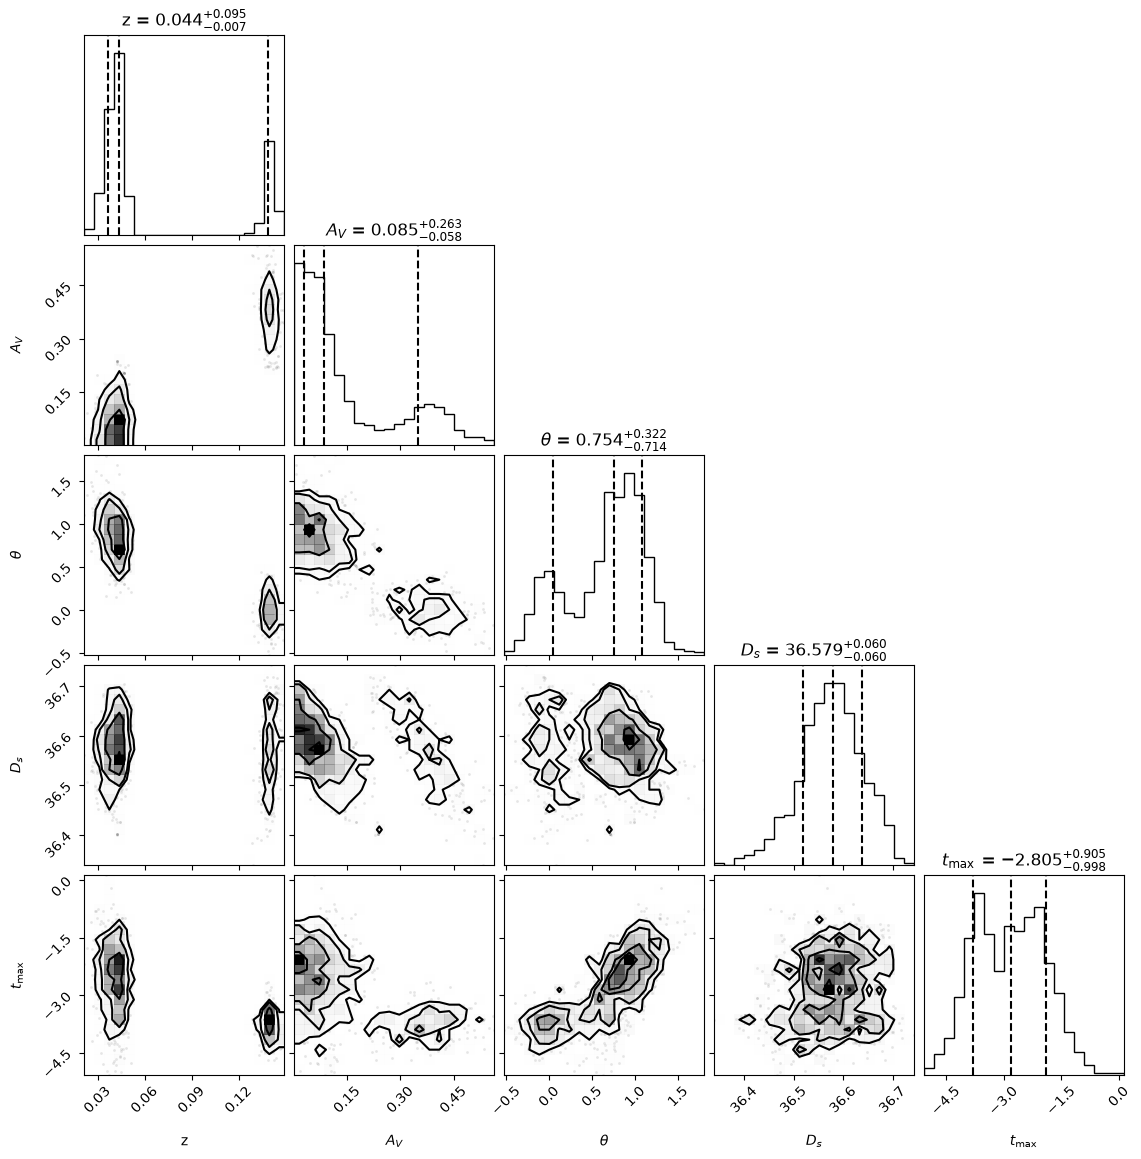

In [110]:
keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_low[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)

plt.show()

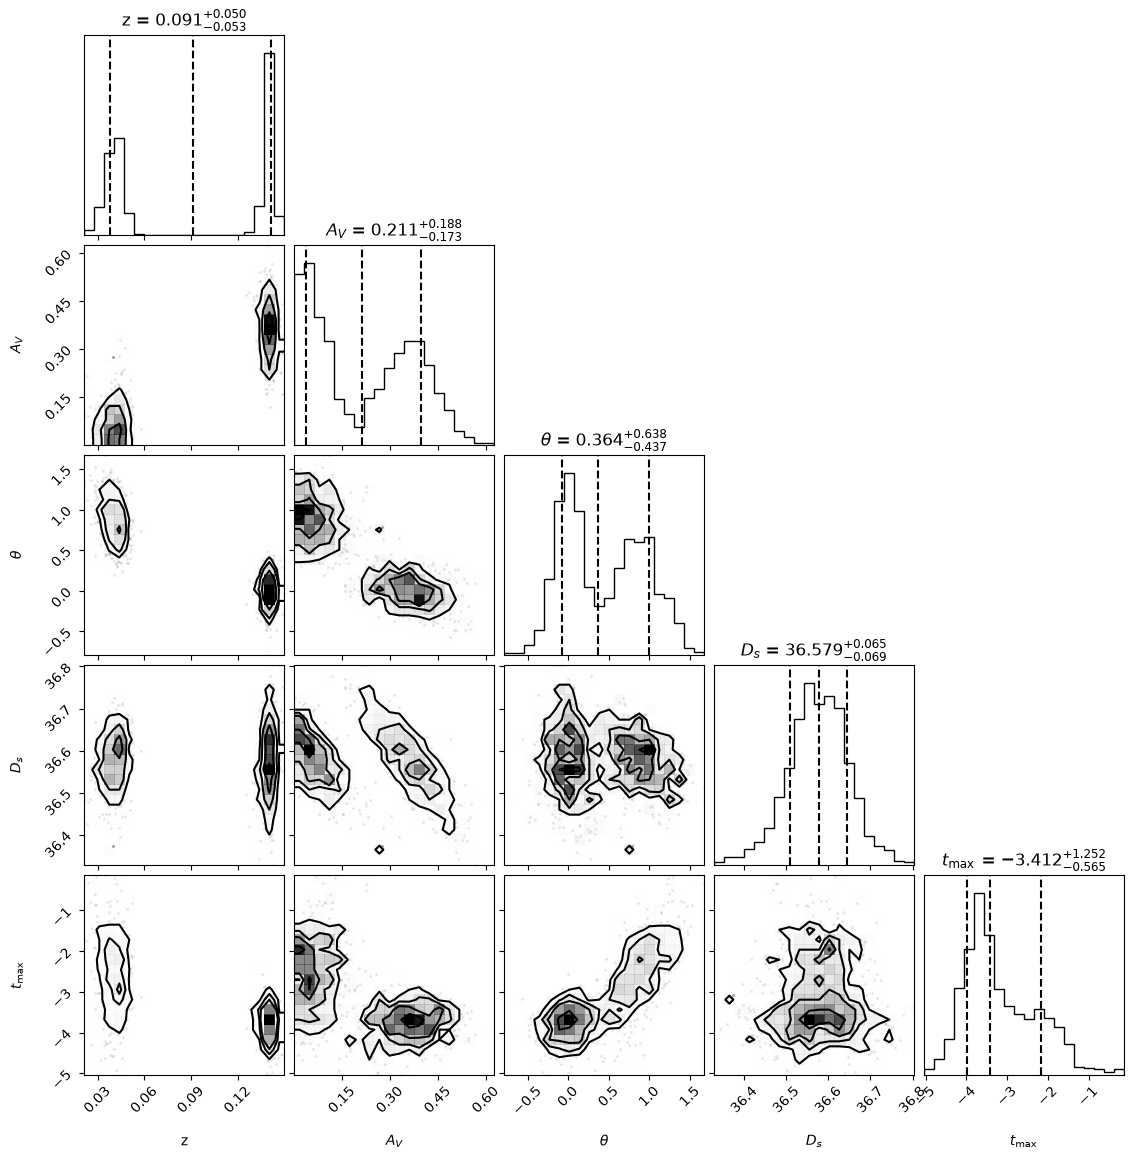

In [111]:
keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_mid[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)

plt.show()

### Changing z input to guassian

In [113]:
import inspect
from bayesn import SEDmodel

print(inspect.getfile(SEDmodel))

print(inspect.getsource(SEDmodel.fit_from_file))

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py
    def fit_from_file(self, path, filt_map={}, peak_mjd_key='SEARCH_PEAKMJD', print_summary=True, file_prefix=None,
                      drop_bands=[], fix_tmax=False, fix_theta=False, fix_AV=False, RV=False, mu_R=False, sigma_R=False,
                      mag=False, photoz=False, z_prior_err=None, z_pdf=None, z_quantiles=None, chain_method='parallel'):
        """
        Method to fit light curve contained in SNANA-format text file using BayeSN model

        Parameters
        ----------
        path: str
            Path to SNANA-format text file containing data to be fit
        filt_map: dict, optional
            Dictionary providing mapping between filter names in file and BayeSN filters. Defaults to empty dictionary
        peak_mjd_key: str, optional
            Key to be used for peak MJD in SNANA text file meta. Defaults to 'SEARCH_PEAKMJD'
        print_summary: Boolean, optional
            

In [115]:
zq_broad = jnp.arange(0, 1, 0.1)
zq_mid   = jnp.linspace(0, 0.30, 10)
zq_low   = jnp.linspace(0, 0.15, 10)

In [118]:
import numpy as np
from scipy.stats import truncnorm

In [119]:
def make_gaussian_z_quantiles(z_mean, z_sigma, z_min=0.0, z_max=0.30, n=101):
    
    # Bounds expressed in units of sigma
    a = (z_min - z_mean) / z_sigma
    b = (z_max - z_mean) / z_sigma
    
    # Avoid exact 0 and 1 for inverse CDF
    probs = np.linspace(1e-4, 1 - 1e-4, n)

    # Quantiles of a truncated Gaussian
    vals = truncnorm.ppf(
        probs,
        a=a,
        b=b,
        loc=z_mean,
        scale=z_sigma
    )

    return probs, vals

In [122]:
z_center = 0.10

zq_gauss_broad = make_gaussian_z_quantiles(
    z_mean=z_center,
    z_sigma=0.10,
    z_min=0.0,
    z_max=0.30
)

zq_gauss_mid = make_gaussian_z_quantiles(
    z_mean=z_center,
    z_sigma=0.05,
    z_min=0.0,
    z_max=0.30
)

zq_gauss_narrow = make_gaussian_z_quantiles(
    z_mean=z_center,
    z_sigma=0.02,
    z_min=0.0,
    z_max=0.30
)

In [125]:
model_gauss_broad = SEDmodel(load_model="T21_model")

samples_gauss_broad, props_gauss_broad = model_gauss_broad.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_gauss_broad,
    drop_bands=[],                 # IMPORTANT: fresh list
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  
sample: 100%|█| 500/500 [02:34<00:00,  3.23it/s, 31 steps of size 8.65e-02. acc. prob
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  
sample: 100%|█| 500/500 [02:35<00:00,  3.21it/s, 63 steps of size 8.00e-02. acc. prob
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  
sample: 100%|█| 500/500 [04:16<00:00,  1.95it/s, 63


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.07      0.06      0.06      0.00      0.15    145.05      1.02
          Ds[0]     36.57      0.07     36.58     36.48     36.69    158.97      1.02
 eps_tform[0,0]     -0.47      0.84     -0.46     -1.85      0.93    976.02      1.00
 eps_tform[0,1]      0.98      0.84      1.01     -0.27      2.41    511.70      1.01
 eps_tform[0,2]      0.13      0.86      0.10     -1.25      1.48   1216.29      1.00
 eps_tform[0,3]     -0.07      0.90     -0.03     -1.55      1.36   1103.37      1.00
 eps_tform[0,4]      1.21      0.70      1.21      0.05      2.30    780.36      1.00
 eps_tform[0,5]     -0.20      0.78     -0.16     -1.58      0.98   1025.82      1.00
 eps_tform[0,6]      0.68      0.82      0.65     -0.66      2.08    222.09      1.02
 eps_tform[0,7]     -0.36      0.74     -0.36     -1.45      0.87    675.34      1.01
 eps_tform[0,8]     -1.38      0.73     -1.36     -2.

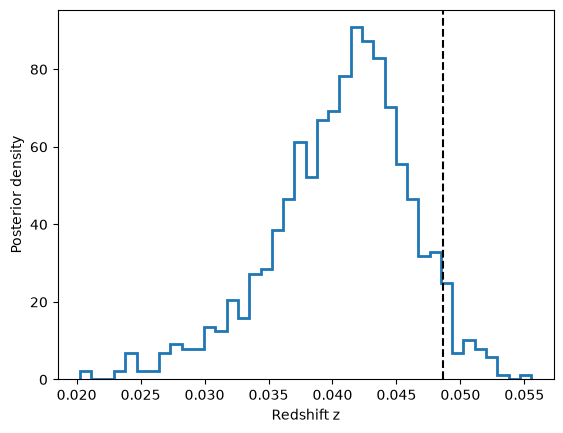

In [129]:
z_gauss_broad = np.asarray(samples_gauss_broad["z"]).reshape(-1)

plt.hist(z_gauss_broad, bins=40, density=True, histtype="step", linewidth=2)
plt.axvline(fixed_z, color="black", linestyle="--")
plt.xlabel("Redshift z")
plt.ylabel("Posterior density")
plt.show()


### On different transient 

In [4]:
snid = "ASASSN-15so"

zq_broad = jnp.arange(0, 1, 0.1)

# narrower low-z distribution
zq_low = jnp.linspace(0.0, 0.15, 10)

# intermediate
zq_mid = jnp.linspace(0.0, 0.30, 10)

In [9]:
model_broad = SEDmodel(load_model="T21_model")

samples_broad, props_broad = model_broad.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [06:30<00:00,  1.28it/s, 255 steps of size 2.13e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [06:12<00:00,  1.34it/s, 255 steps of size 2.36e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.06      0.00      0.14      3.97      1.42
          Ds[0]     32.93      0.21     32.83     32.76     33.30      2.06      5.73
 eps_tform[0,0]     -1.35      5.10      1.32    -10.41      2.31      2.02      9.54
 eps_tform[0,1]      1.40      0.54      1.31      0.59      2.29     13.44      1.10
 eps_tform[0,2]      1.54      0.53      1.58      0.61      2.33     62.02      1.03
 eps_tform[0,3]      0.95      0.91      0.86     -0.37      2.58      6.34      1.20
 eps_tform[0,4]     -0.34      1.25     -0.75     -1.79      1.95      2.36      2.49
 eps_tform[0,5]      5.07      8.23      0.54     -0.39     19.62      2.01     18.19
 eps_tform[0,6]     -0.41      0.56     -0.38     -1.30      0.49     48.77      1.06
 eps_tform[0,7]     -0.10      0.52     -0.07     -0.99      0.74     19.00      1.29
 eps_tform[0,8]      0.61      1.24      0.20     -0.

In [10]:
model_low = SEDmodel(load_model="T21_model")

samples_low, props_low = model_low.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_low,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [05:20<00:00,  1.56it/s, 255 steps of size 2.46e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [04:52<00:00,  1.71it/s, 255 steps of size 2.50e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.05      0.08      0.00      0.16    420.22      1.00
          Ds[0]     32.82      0.05     32.82     32.75     32.90    399.63      1.02
 eps_tform[0,0]      1.59      0.62      1.61      0.56      2.52    616.15      1.01
 eps_tform[0,1]      1.55      0.55      1.53      0.60      2.38    959.94      1.00
 eps_tform[0,2]      1.48      0.52      1.48      0.68      2.35    952.05      1.00
 eps_tform[0,3]      0.66      0.70      0.64     -0.57      1.77    961.34      1.00
 eps_tform[0,4]     -1.02      0.56     -1.01     -1.92     -0.15    531.57      1.00
 eps_tform[0,5]      0.35      0.51      0.36     -0.47      1.20    713.42      1.00
 eps_tform[0,6]     -0.51      0.57     -0.49     -1.43      0.42    440.07      1.01
 eps_tform[0,7]      0.00      0.41     -0.02     -0.70      0.64    606.90      1.00
 eps_tform[0,8]     -0.08      0.54     -0.08     -0.

In [11]:
model_mid = SEDmodel(load_model="T21_model")

samples_mid, props_mid = model_mid.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=zq_mid,
    chain_method="sequential",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [05:33<00:00,  1.50it/s, 255 steps of size 2.43e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [07:50<00:00,  1.06it/s, 255 steps of size 1.87e-02. acc. pro
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2793: UserWarning: Missing a plate statement for batch dimension -2 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.08      0.05      0.08      0.00      0.15    357.28      1.01
          Ds[0]     32.82      0.04     32.82     32.75     32.89    246.34      1.03
 eps_tform[0,0]      1.58      0.64      1.59      0.47      2.52    702.26      1.01
 eps_tform[0,1]      1.52      0.57      1.51      0.63      2.48    922.77      1.00
 eps_tform[0,2]      1.49      0.54      1.48      0.62      2.35    932.63      1.00
 eps_tform[0,3]      0.64      0.70      0.62     -0.28      1.99   1095.83      1.00
 eps_tform[0,4]     -0.99      0.58     -0.97     -1.93     -0.04    623.79      1.00
 eps_tform[0,5]      0.33      0.51      0.32     -0.48      1.19    541.67      1.01
 eps_tform[0,6]     -0.49      0.55     -0.51     -1.42      0.36    314.32      1.02
 eps_tform[0,7]     -0.03      0.43     -0.03     -0.76      0.64    560.78      1.00
 eps_tform[0,8]     -0.05      0.54     -0.05     -0.

In [14]:
import sncosmo

meta, lcdata = sncosmo.read_snana_ascii(
    str(sn_file),
    default_tablename="OBS"
)

z_spec = meta["REDSHIFT_HELIO"]

print(z_spec)

0.0070224


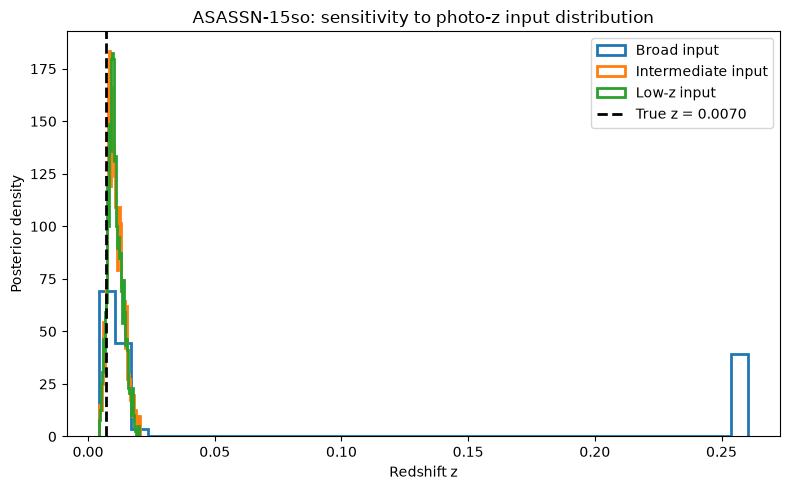

In [16]:
z_broad = np.asarray(samples_broad["z"]).reshape(-1)
z_low   = np.asarray(samples_low["z"]).reshape(-1)
z_mid   = np.asarray(samples_mid["z"]).reshape(-1)

plt.figure(figsize=(8, 5))

plt.hist(
    z_broad,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Broad input",
)

plt.hist(
    z_mid,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Intermediate input",
)

plt.hist(
    z_low,
    bins=40,
    density=True,
    histtype="step",
    linewidth=2,
    label="Low-z input",
)

plt.axvline(
    z_spec,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"True z = {z_spec:.4f}",
)

plt.xlabel("Redshift z")
plt.ylabel("Posterior density")
plt.title(f"{snid}: sensitivity to photo-z input distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
for name, zvals in {
    "broad": z_broad,
    "mid": z_mid,
    "low": z_low,
}.items():

    q16, q50, q84 = np.percentile(
        zvals,
        [16, 50, 84],
    )


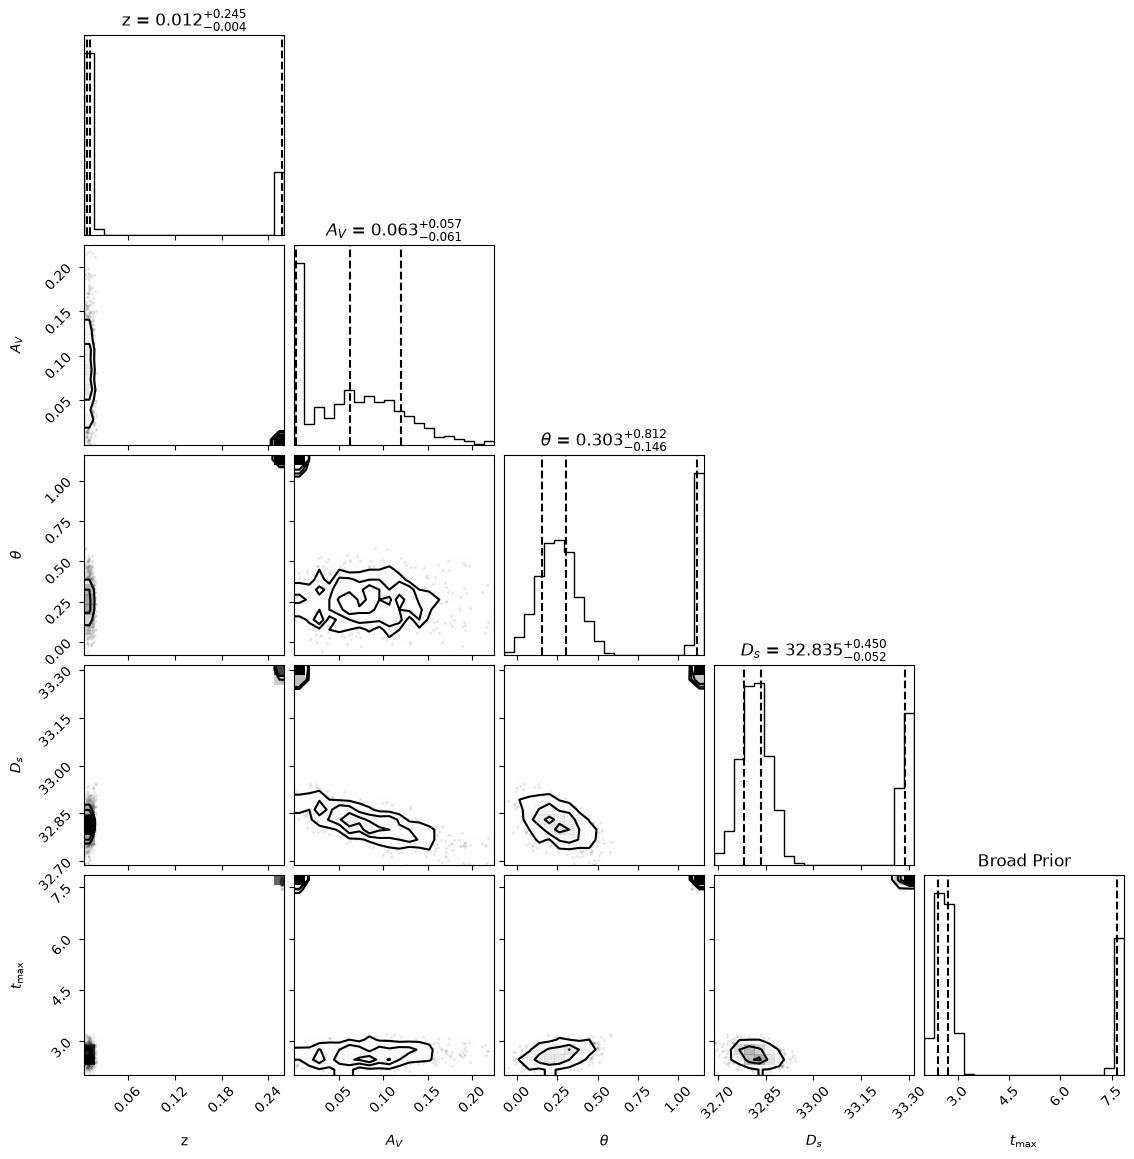

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import corner

keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_broad[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)
plt.title("Broad Prior")

plt.show()

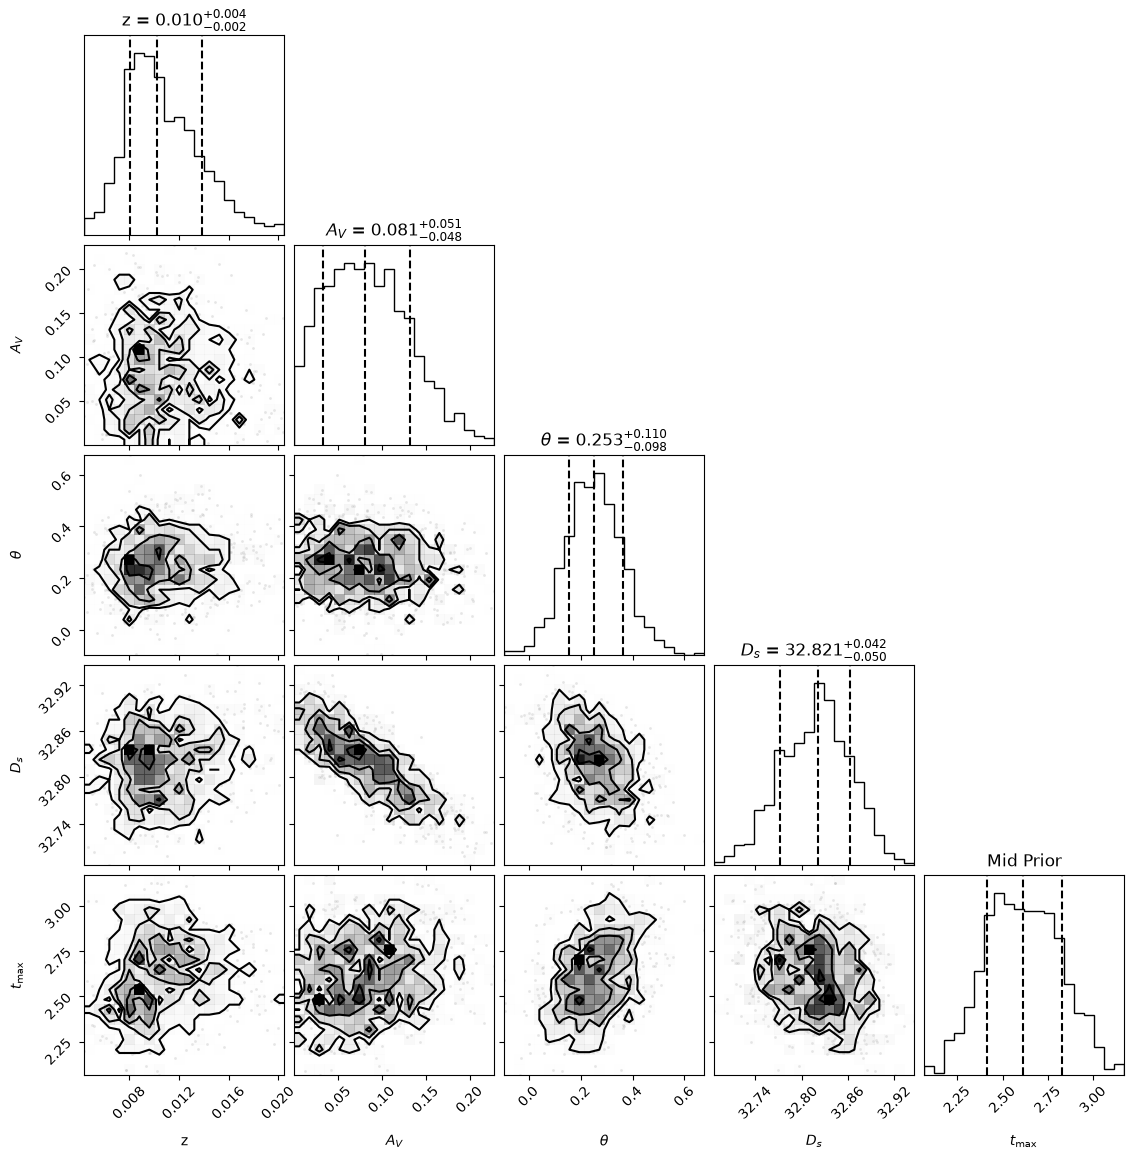

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import corner

keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_mid[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)
plt.title("Mid Prior")

plt.show()

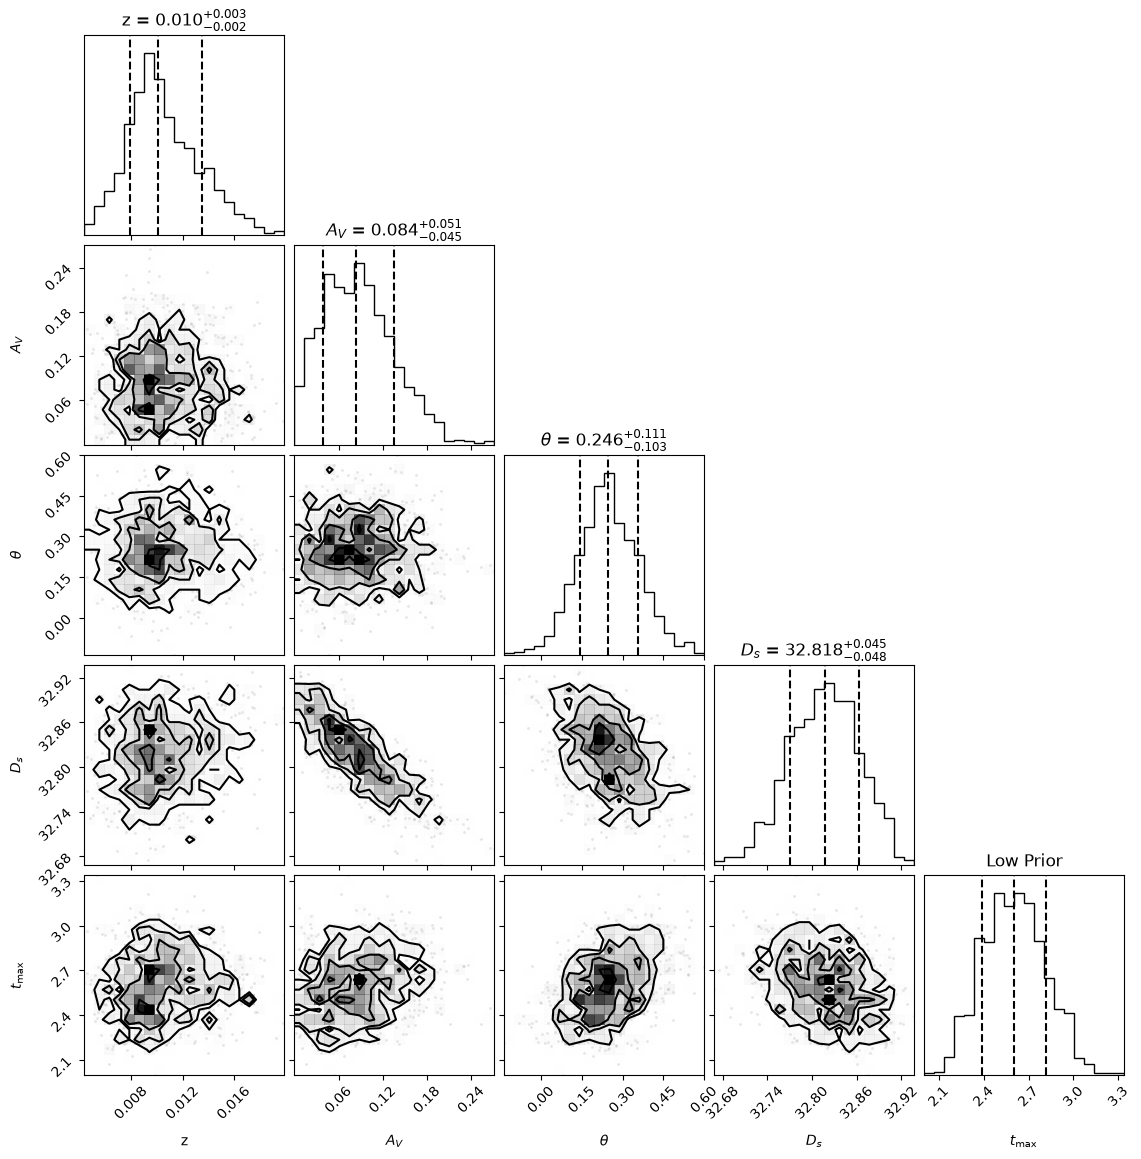

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import corner

keys = ["z", "AV", "theta", "Ds", "tmax"]

arr = np.column_stack([
    np.asarray(samples_low[k]).reshape(-1)
    for k in keys
])

fig = corner.corner(
    arr,
    labels=["z", r"$A_V$", r"$\theta$", r"$D_s$", r"$t_{\max}$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84]
)
plt.title("Low Prior")

plt.show()

In [21]:

# Reload observed data
meta, lcdata = sncosmo.read_snana_ascii(
    str(sn_file),
    default_tablename="OBS"
)

data = lcdata["OBS"].to_pandas()

mjd = data["MJD"].values
flux_obs = data["FLUXCAL"].values
flux_err = data["FLUXCALERR"].values
filters_obs = data["FLT"].values

peak_mjd = meta["SEARCH_PEAKMJD"]
ebv_mw = meta["MWEBV"]

# Time grid around peak
phase_grid = np.linspace(-10, 40, 200)

# Bands used for this SN
bands = ["g_PS1", "r_PS1", "i_PS1", "z_PS1"]

mid_samples_plot = {
    k: np.asarray(v)
    for k, v in samples_mid.items()
}

if "mu" not in mid_samples_plot:
    mid_samples_plot["mu"] = mid_samples_plot["Ds"]

if "delM" not in mid_samples_plot:
    mid_samples_plot["delM"] = np.zeros_like(
        mid_samples_plot["Ds"]
    )

In [22]:
model_mid_plot = SEDmodel(load_model="T21_model")

mid_flux = model_mid_plot.get_flux_from_chains(
    phase_grid,
    bands,
    mid_samples_plot,
    props_mid[0],      # nominal/reference z from file
    props_mid[1],      # MW E(B-V)
    mag=False,
    num_samples=100,
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|██████████████████████████████████████████████████| 1/1 [00:11<00:00, 11.88s/it]


In [23]:
mid_flux = np.asarray(mid_flux)

mid_median = np.median(mid_flux, axis=(0, 1))
mid_lo = np.percentile(mid_flux, 16, axis=(0, 1))
mid_hi = np.percentile(mid_flux, 84, axis=(0, 1))

In [29]:
plot_model = SEDmodel(
    load_model="T21_model"
)
t = np.linspace(-10, 40, 200)

bands = [
    "g_PS1",
    "r_PS1",
    "i_PS1",
    "z_PS1",
]

z_ref, ebv_mw = props_mid

samples_mid_plot = {
    k: np.asarray(v)
    for k, v in samples_mid.items()
}

# photo-z fits may not contain these
if "mu" not in samples_mid_plot:
    samples_mid_plot["mu"] = samples_mid_plot["Ds"]

if "delM" not in samples_mid_plot:
    samples_mid_plot["delM"] = np.zeros_like(
        samples_mid_plot["Ds"]
    )

flux_grid_mid = plot_model.get_flux_from_chains(
    t,
    bands,
    samples_mid_plot,
    z_ref,
    ebv_mw,
    mag=False,
    num_samples=1000,
)

fit_mid = flux_grid_mid.mean(axis=(0, 1)809-----------------------------------------------------------------------------------------------------------------------------------------------56708976456544-=88888888811111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111ooouuuuououuuououuuuuuuuuutttttyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyy1uoty
fit_err_mid = flux_grid_mid.std(axis=(0, 1))

print("flux_grid_mid:", flux_grid_mid.shape)
print("fit_mid:", fit_mid.shape)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model
Getting best fit light curves from chains...


100%|██████████████████████████████████████████████████| 1/1 [01:12<00:00, 72.61s/it]


flux_grid_mid: (1, 1000, 4, 200)
fit_mid: (4, 200)


In [33]:
snid = "PS15asb"
meta, lcdata = sncosmo.read_snana_ascii(
    str(sn_file),
    default_tablename="OBS"
)

lc = lcdata["OBS"].to_pandas().sort_values("MJD").copy()

peak_mjd = float(meta["SEARCH_PEAKMJD"])

plot_t = t + peak_mjd



NameError: name 'fit' is not defined

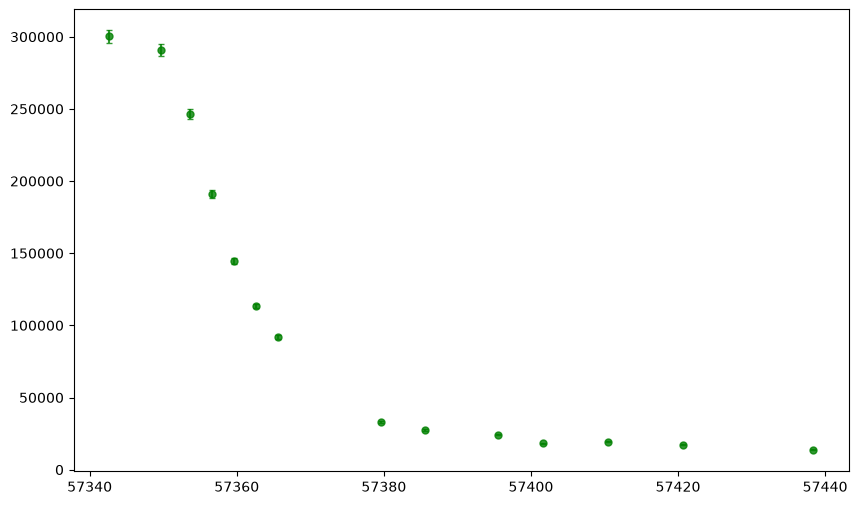

In [34]:
colors = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for b_ind, band in enumerate(["g", "r", "i", "z"]):

    band_data = lc[
        lc["FLT"] == band
    ]

    # observed data
    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=colors[band],
        alpha=0.8,
        label=f"{band} data",
    )

    # BayeSN posterior mean
    ax.plot(
        plot_t,
        fit[b_ind],
        color=colors[band],
        linewidth=2,
        label=f"{band} BayeSN",
    )

    # posterior scatter
    ax.fill_between(
        plot_t,
        fit[b_ind] - fit_err[b_ind],
        fit[b_ind] + fit_err[b_ind],
        color=colors[band],
        alpha=0.2,
    )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"BayeSN fit: {snid}")

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()